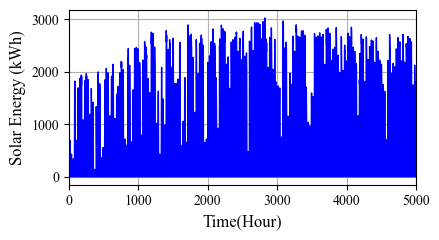

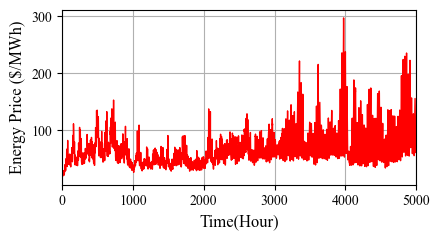

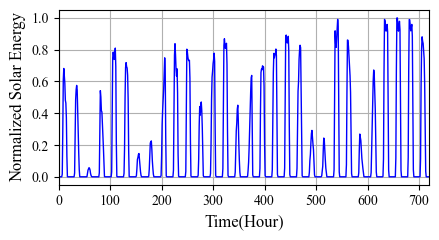

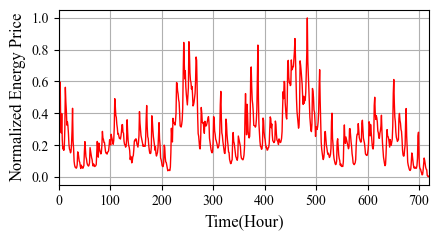

In [ ]:
#%%
#!pip install pandas
#pip install seaborn
import os
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import math
import gymnasium as gym
from scipy import stats as _stats
env = gym.make('CartPole-v1')
from sklearn.metrics import mean_squared_error, mean_absolute_error
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams.update({
    "axes.titlesize": 12,   # title font size
    "axes.labelsize": 12,   # x and y label size
    "xtick.labelsize": 10,  # x tick label size
    "ytick.labelsize": 10   # y tick label size
})

mpl.rcParams['savefig.transparent'] = False

base_path = r'E:\My_Project\MAQ_EMS_Microgrid'
image_dir = 'images'                        # manualy create images folder in the root folder
full_image_path = os.path.join(base_path, image_dir)


# Helper function to save figures
def save_figure(filename):
    """Saves the current matplotlib figure to the predefined path."""
    save_path = os.path.join(full_image_path, filename)
    plt.savefig(save_path)
    


#
file_path = 'solar.csv'
# Read the CSV file into a pandas DataFrame
solar_data = pd.read_csv(file_path)
#print(solar_data.head())
solar_generation_kw = np.array(solar_data['solar_generation_kw']) #solar_generation_mw
#print(solar_generation_mw)
solar_generation_kw = np.where(solar_generation_kw < 0, 0, solar_generation_kw)

# prompt: Take 120 values from solar_generation_mw
solar_generation_kw_120 = solar_generation_kw[:120]
#print(solar_generation_mw_120)
#
#
#
file_path = 'price.csv'
# Read the CSV file into a pandas DataFrame
price_data = pd.read_csv(file_path)
#print(price_data.head())
energy_price_usd = np.array(price_data['system_energy_price_da']) #system_energy_price_da
energy_price_usd = np.where(energy_price_usd < 0, 0, energy_price_usd)
#print(energy_price_usd)
#
#
#
start_index = 312
num_values = 720

# Extract the specified range of values
solar_generation_subset = solar_generation_kw[start_index : start_index + num_values] #solar data

energy_price_usd_subset = energy_price_usd[start_index - 68 : start_index + num_values -68] #previous was 200 not 68

s_max = np.max(solar_generation_subset)
s_min = np.min(solar_generation_subset)
solar_data_norm = (solar_generation_subset - s_min) / (s_max-s_min)

#print('Original Solar Data')
#print(solar_data)

p_max=np.max(energy_price_usd_subset)
p_min=np.min(energy_price_usd_subset)
price_data_norm = (energy_price_usd_subset - p_min) / (p_max - p_min)

# Plot the full data
plt.figure(figsize=(4.5, 2.5))
plt.plot(solar_generation_kw[:5000], color='b', linewidth=1)
plt.xlim(0, len(solar_generation_kw[:5000]))
plt.xlabel('Time(Hour)')
plt.ylabel('Solar Energy (kWh)')
plt.grid(True)
plt.tight_layout()
save_figure('solar.eps')

plt.figure(figsize=(4.5, 2.5))
plt.plot(energy_price_usd[:5000], color='r', linewidth=1)
plt.xlim(0, len(energy_price_usd[:5000]))
plt.xlabel('Time(Hour)')
plt.ylabel('Energy Price ($/MWh)')
plt.grid(True)
plt.tight_layout()
save_figure('price.eps')

# Plot the full data
plt.figure(figsize=(4.5, 2.5))
plt.plot(solar_data_norm, color='b', linewidth=1)
plt.xlim(0, len(solar_data_norm))
plt.xlabel('Time(Hour)')
plt.ylabel('Normalized Solar Energy')
plt.grid(True)
plt.tight_layout()
save_figure('solar_use.eps')


plt.figure(figsize=(4.5, 2.5))
plt.plot(price_data_norm, color='r', linewidth=1)
plt.xlim(0, len(price_data_norm))
plt.xlabel('Time(Hour)')
plt.ylabel('Normalized Energy Price')
plt.grid(True)
plt.tight_layout()
save_figure('price_use.eps')



Solar Prediction (FFNN) RMSE: 0.0691
Solar Prediction (FFNN) MAE:  0.0393

Solar Baselines (normalized)
Solar Persistence   RMSE: 0.1742, MAE: 0.0844
Solar Seasonal(24h) RMSE: 0.1441, MAE: 0.0576


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.



Price Prediction (FFNN) RMSE: 0.0432
Price Prediction (FFNN) MAE:  0.0312

Price Baselines (normalized)
Price Persistence   RMSE: 0.0576, MAE: 0.0396
Price Seasonal(24h) RMSE: 0.1333, MAE: 0.1142

================ Summary Table (Normalized) ================
Model                     | PV RMSE | PV MAE | Price RMSE | Price MAE
------------------------------------------------------------
Persistence (B1)          |  0.1742 | 0.0844 |    0.0576 |   0.0396
Seasonal persistence (B2) |  0.1441 | 0.0576 |    0.1333 |   0.1142
FFNN (1-step)             |  0.0691 | 0.0393 |    0.0432 |   0.0312


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


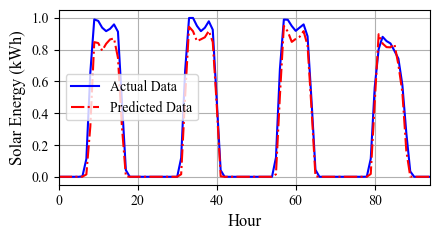

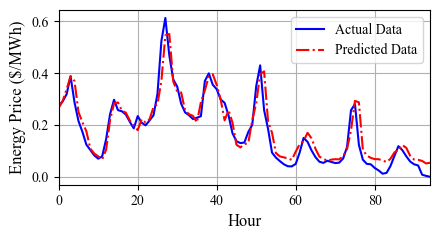

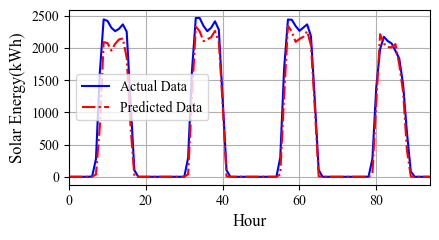

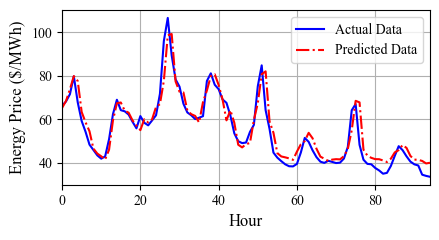

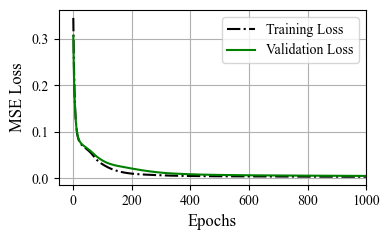

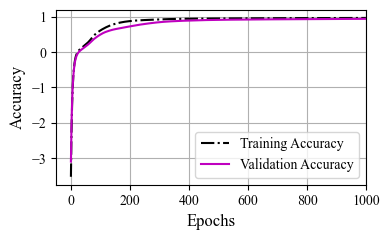

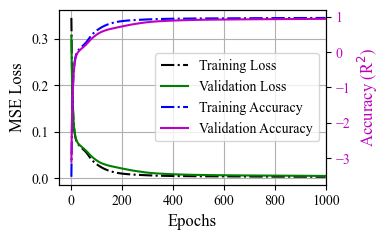

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


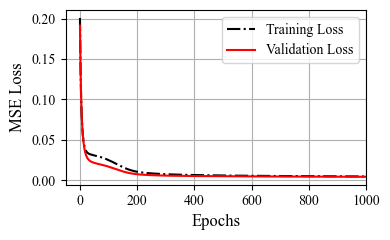

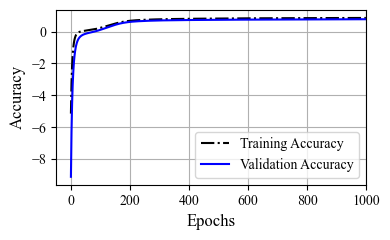

In [2]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Activation function and its derivative (ReLU)

def leaky_relu(x, alpha):
    return np.where(x > 0, x, alpha * x)

def leaky_relu_derivative(x, alpha):
    return np.where(x > 0, 1, alpha)

def huber_loss(y_true, y_pred, delta = 100):
    error = y_true - y_pred
    is_small_error = np.abs(error) <= delta
    squared_loss = 0.5 * error**2
    linear_loss = delta * (np.abs(error) - 0.5 * delta)
    return np.mean(np.where(is_small_error, squared_loss, linear_loss))

def huber_loss_derivative(y_true, y_pred, delta =100):
    error = y_true - y_pred
    derivative = np.where(np.abs(error) <= delta, -error, -delta * np.sign(error))
    return derivative / y_true.size

def softplus(x):
    return np.log1p(np.exp(x))

def softplus_derivative(x):
    return 1 / (1 + np.exp(-x))

def mse_loss(y_true, y_pred, W1=None, W2=None, lambda_reg=0.001):
    mse = np.mean((y_true - y_pred) ** 2)
    if W1 is not None and W2 is not None:
        l2 = lambda_reg * (np.sum(W1**2) + np.sum(W2**2))
        return mse + l2
    return mse

def mse_loss_derivative(y_true, y_pred):
    return 2 * (y_pred - y_true) / y_true.size


Losses = []

# Neural network class definition
class CustomNeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size, learning_rate):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.learning_rate = learning_rate

        self.W1 = np.random.randn(self.input_size, self.hidden_size) * 0.1
        self.b1 = np.zeros((1, self.hidden_size))
        self.W2 = np.random.randn(self.hidden_size, self.hidden_size) * 0.1
        self.b2 = np.zeros((1, self.hidden_size))
        self.W3 = np.random.randn(self.hidden_size, self.output_size) * 0.1
        self.b3 = np.zeros((1, self.output_size))

    def forward(self, X):
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = leaky_relu(self.Z1, alpha=0.01)
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = leaky_relu(self.Z2, alpha=0.01)
        self.Z3 = np.dot(self.A2, self.W3) + self.b3
        self.A3 = softplus(self.Z3)
        return self.A3

    def backward(self, X, Y, output):
        loss_grad = mse_loss_derivative(Y, output)

        dW3 = np.dot(self.A2.T, loss_grad)
        db3 = np.sum(loss_grad, axis=0, keepdims=True)

        hidden_grad2 = np.dot(loss_grad, self.W3.T) * leaky_relu_derivative(self.Z2, alpha=0.001)
        dW2 = np.dot(self.A1.T, hidden_grad2)
        db2 = np.sum(hidden_grad2, axis=0, keepdims=True)

        hidden_grad1 = np.dot(hidden_grad2, self.W2.T) * leaky_relu_derivative(self.Z1, alpha=0.001)
        dW1 = np.dot(X.T, hidden_grad1)
        db1 = np.sum(hidden_grad1, axis=0, keepdims=True)

        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1
        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2
        self.W3 -= self.learning_rate * dW3
        self.b3 -= self.learning_rate * db3

    def accuracy(self, y_true, y_pred):
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        return 1 - ss_res / (ss_tot + 1e-6)   # R² score

    def train(self, X_train, Y_train, X_val, Y_val, epochs):
        train_losses, val_losses = [], []
        train_accs, val_accs = [], []

        for epoch in range(epochs):
            # ---- Training forward + backward ----
            output_train = self.forward(X_train)
            loss_train = mse_loss(Y_train, output_train, W1=None, W2=None, lambda_reg=0.001)
            acc_train = self.accuracy(Y_train, output_train)

            self.backward(X_train, Y_train, output_train)  # update weights using train set only

            # ---- Validation forward only ----
            output_val = self.forward(X_val)
            loss_val = mse_loss(Y_val, output_val, W1=None, W2=None, lambda_reg=0.001)
            acc_val = self.accuracy(Y_val, output_val)

            # Store history
            train_losses.append(loss_train)
            val_losses.append(loss_val)
            train_accs.append(acc_train)
            val_accs.append(acc_val)

        return train_losses, val_losses, train_accs, val_accs


# Number of hours in a day
n_hours = 24
n_days = len(solar_data_norm) // n_hours
train_days = 25
test_days = n_days - train_days

# ------------------------------
# Prepare training data (hour by hour)
# Input: 24 hours
# Output: next 1 hour
# ------------------------------
Xs, Ys, Xp, Yp = [], [], [], []

for i in range(train_days * n_hours - n_hours - 1):
    Xs.append(solar_data_norm[i:i+n_hours])       # past 24h
    Ys.append(solar_data_norm[i+n_hours])         # next 1h
    Xp.append(price_data_norm[i:i+n_hours])       # past 24h
    Yp.append(price_data_norm[i+n_hours])         # next 1h

Xs = np.array(Xs)
Ys = np.array(Ys).reshape(-1, 1)  # (samples, 1)
Xp = np.array(Xp)
Yp = np.array(Yp).reshape(-1, 1)

val_ratio = 0.2
split_idx = int(len(Xs) * (1 - val_ratio))

Xs_train, Ys_train = Xs[:split_idx], Ys[:split_idx]
Xs_val, Ys_val = Xs[split_idx:], Ys[split_idx:]

# ------------------------------
# Initialize custom NNs (Solar)
# ------------------------------
nns = CustomNeuralNetwork(input_size=24, hidden_size=24, output_size=1, learning_rate=0.1)
train_losses_solar, val_losses_solar, train_accs_solar, val_accs_solar = nns.train(
    Xs_train, Ys_train, Xs_val, Ys_val, epochs=5000
)
train_losses_solar = train_losses_solar[0:1000]
val_losses_solar   = val_losses_solar[0:1000]
train_accs_solar   = train_accs_solar[0:1000]
val_accs_solar     = val_accs_solar[0:1000]

# ------------------------------
# Prepare testing data
# ------------------------------
Xst, Yst, Xpt, Ypt = [], [], [], []

for i in range(train_days * n_hours, (train_days + test_days) * n_hours - n_hours - 1):
    Xst.append(solar_data_norm[i:i+n_hours])
    Yst.append(solar_data_norm[i+n_hours])
    Xpt.append(price_data_norm[i:i+n_hours])
    Ypt.append(price_data_norm[i+n_hours])

Xst = np.array(Xst)
Yst = np.array(Yst).reshape(-1, 1)
Xpt = np.array(Xpt)
Ypt = np.array(Ypt).reshape(-1, 1)

# ------------------------------
# Solar: Hour-by-hour prediction (FFNN)
# ------------------------------
solar_predicted = []

for i in range(len(Xst)):
    prediction = nns.forward(Xst[i].reshape(1, -1))
    solar_predicted.append(prediction.flatten()[0])

solar_actual = Yst.flatten()
solar_predicted = np.array(solar_predicted)

rmse_solar = np.sqrt(mean_squared_error(solar_actual, solar_predicted))
mae_solar = mean_absolute_error(solar_actual, solar_predicted)

print(f"Solar Prediction (FFNN) RMSE: {rmse_solar:.4f}")
print(f"Solar Prediction (FFNN) MAE:  {mae_solar:.4f}")

# ------------------------------
# Baselines: Persistence + Seasonal Persistence (Solar)
# ------------------------------
# B1: Plain persistence -> y_hat(t+1) = y(t)  -> last element of the 24h window
solar_persist_pred = Xst[:, -1]

# B2: Daily seasonal persistence -> y_hat(t+1) = y(t+1-24) -> first element of the 24h window
solar_seasonal_pred = Xst[:, 0]

rmse_solar_persist = np.sqrt(mean_squared_error(solar_actual, solar_persist_pred))
mae_solar_persist  = mean_absolute_error(solar_actual, solar_persist_pred)

rmse_solar_seasonal = np.sqrt(mean_squared_error(solar_actual, solar_seasonal_pred))
mae_solar_seasonal  = mean_absolute_error(solar_actual, solar_seasonal_pred)

print("\nSolar Baselines (normalized)")
print(f"Solar Persistence   RMSE: {rmse_solar_persist:.4f}, MAE: {mae_solar_persist:.4f}")
print(f"Solar Seasonal(24h) RMSE: {rmse_solar_seasonal:.4f}, MAE: {mae_solar_seasonal:.4f}")


# ------------------------------
# Initialize custom NNs (Price)
# ------------------------------
val_ratio = 0.2
split_idx = int(len(Xs) * (1 - val_ratio))

Xp_train, Yp_train = Xp[:split_idx], Yp[:split_idx]
Xp_val, Yp_val = Xp[split_idx:], Yp[split_idx:]

nnp = CustomNeuralNetwork(input_size=24, hidden_size=24, output_size=1, learning_rate=0.1)
train_losses_price, val_losses_price, train_accs_price, val_accs_price = nnp.train(
    Xp_train, Yp_train, Xp_val, Yp_val, epochs=5000
)
train_losses_price = train_losses_price[0:1000]
val_losses_price   = val_losses_price[0:1000]
train_accs_price   = train_accs_price[0:1000]
val_accs_price     = val_accs_price[0:1000]

# ------------------------------
# Price: Hour-by-hour prediction (FFNN)
# ------------------------------
price_predicted = []

for i in range(len(Xpt)):
    pred = nnp.forward(Xpt[i].reshape(1, -1))
    price_predicted.append(pred.flatten()[0])

price_actual = Ypt.flatten()
price_predicted = np.array(price_predicted)

rmse_price = np.sqrt(mean_squared_error(price_actual, price_predicted))
mae_price = mean_absolute_error(price_actual, price_predicted)

print(f"\nPrice Prediction (FFNN) RMSE: {rmse_price:.4f}")
print(f"Price Prediction (FFNN) MAE:  {mae_price:.4f}")

# ------------------------------
# Baselines: Persistence + Seasonal Persistence (Price)
# ------------------------------
price_persist_pred  = Xpt[:, -1]  # B1
price_seasonal_pred = Xpt[:, 0]   # B2

rmse_price_persist = np.sqrt(mean_squared_error(price_actual, price_persist_pred))
mae_price_persist  = mean_absolute_error(price_actual, price_persist_pred)

rmse_price_seasonal = np.sqrt(mean_squared_error(price_actual, price_seasonal_pred))
mae_price_seasonal  = mean_absolute_error(price_actual, price_seasonal_pred)

print("\nPrice Baselines (normalized)")
print(f"Price Persistence   RMSE: {rmse_price_persist:.4f}, MAE: {mae_price_persist:.4f}")
print(f"Price Seasonal(24h) RMSE: {rmse_price_seasonal:.4f}, MAE: {mae_price_seasonal:.4f}")


# ------------------------------
# Optional: one clean summary table printout (console)
# ------------------------------
print("\n================ Summary Table (Normalized) ================")
print("Model                     | PV RMSE | PV MAE | Price RMSE | Price MAE")
print("------------------------------------------------------------")
print(f"Persistence (B1)          | {rmse_solar_persist:7.4f} | {mae_solar_persist:6.4f} | {rmse_price_persist:9.4f} | {mae_price_persist:8.4f}")
print(f"Seasonal persistence (B2) | {rmse_solar_seasonal:7.4f} | {mae_solar_seasonal:6.4f} | {rmse_price_seasonal:9.4f} | {mae_price_seasonal:8.4f}")
print(f"FFNN (1-step)             | {rmse_solar:7.4f} | {mae_solar:6.4f} | {rmse_price:9.4f} | {mae_price:8.4f}")
print("============================================================")

# Plot solar
plt.figure(figsize=(4.5, 2.5))
plt.plot(range(len(solar_actual)), solar_actual, label='Actual Data', linestyle = '-', color = 'b')
plt.plot(range(len(solar_predicted)), solar_predicted, label='Predicted Data', linestyle = '-.', color = 'r')
plt.xlim(0, len(solar_predicted)-1)
plt.xlabel('Hour')
plt.ylabel('Solar Energy (kWh)')
plt.legend()
plt.grid(True)
plt.tight_layout()
save_figure('solar_pred.eps')


# Plot price
plt.figure(figsize=(4.5, 2.5))
plt.plot(range(len(price_actual)), price_actual, label='Actual Data', linestyle = '-', color = 'b')
plt.plot(range(len(price_predicted)), price_predicted, label='Predicted Data', linestyle = '-.', color = 'r')
plt.xlim(0, len(price_predicted)-1)
plt.xlabel('Hour')
plt.ylabel('Energy Price ($/MWh)')
plt.legend()
plt.grid(True)
plt.tight_layout()
save_figure('price_pred.eps')


# Denormalized solar Data
solar_actual_data = solar_actual *(s_max - s_min) + s_min    
solar_predicted_data = solar_predicted *(s_max - s_min) + s_min

# Denormalized Price Data
price_actual_data = price_actual *(p_max - p_min) + p_min    
price_predicted_data = price_predicted *(p_max - p_min) + p_min



# Plot solar
plt.figure(figsize=(4.5, 2.5))
plt.plot(range(len(solar_actual_data)), solar_actual_data, label='Actual Data', linestyle = '-', color = 'b')
plt.plot(range(len(solar_predicted_data)), solar_predicted_data, label='Predicted Data', linestyle = '-.', color = 'r')
plt.xlim(0, len(solar_predicted)-1)
plt.xlabel('Hour')
plt.ylabel('Solar Energy(kWh)')
plt.legend()
plt.grid(True)
plt.tight_layout()
save_figure('solar_pred_ac.eps')

# Plot price
plt.figure(figsize=(4.5, 2.5))
plt.plot(range(len(price_actual_data)), price_actual_data, label='Actual Data', linestyle = '-', color = 'b')
plt.plot(range(len(price_predicted_data)), price_predicted_data, label='Predicted Data', linestyle = '-.', color = 'r')
plt.xlim(0, len(price_predicted)-1)
plt.xlabel('Hour')
plt.ylabel('Energy Price ($/MWh)')
plt.legend()
plt.grid(True)
plt.tight_layout()
save_figure('price_pred_ac.eps')


plt.figure(figsize=(4, 2.5))
plt.plot(train_losses_solar, label="Training Loss", linestyle = '-.', color = 'k')
plt.plot(val_losses_solar, label="Validation Loss", color = 'g')
plt.xlim(-50, len(val_losses_solar))
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
save_figure('sloss.eps')

# ------------------------------
# Plot Training vs Validation Accuracy
# ------------------------------
plt.figure(figsize=(4, 2.5))
plt.plot(train_accs_solar, label="Training Accuracy", linestyle = '-.', color = 'k')
plt.plot(val_accs_solar, label="Validation Accuracy", color = 'm')
plt.xlim(-50, len(val_accs_solar))
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
save_figure('saccuracy.eps')


fig, ax1 = plt.subplots(figsize=(4, 2.5))

# --- Plot Losses on left y-axis ---
ax1.plot(train_losses_solar, label="Training Loss", linestyle='-.', color='k')
ax1.plot(val_losses_solar, label="Validation Loss", color='g')
ax1.set_xlabel("Epochs")
ax1.set_ylabel("MSE Loss", color='k')
ax1.tick_params(axis='y', labelcolor='k')
ax1.set_xlim(-50, len(val_losses_solar))

# --- Plot Accuracies on right y-axis ---
ax2 = ax1.twinx()
ax2.plot(train_accs_solar, label="Training Accuracy", linestyle='-.', color='b')
ax2.plot(val_accs_solar, label="Validation Accuracy", color='m')
ax2.set_ylabel("Accuracy (R$^2$)", color='m')
ax2.tick_params(axis='y', labelcolor='m')

# --- Title and grid ---
ax1.grid(True)

# --- Combine legends from both axes ---
lns1, labs1 = ax1.get_legend_handles_labels()
lns2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lns1 + lns2, labs1 + labs2, loc='center right')

fig.tight_layout()
save_figure("solar_loss_accuracy_combined.eps")
plt.show()



plt.figure(figsize=(4, 2.5))
plt.plot(train_losses_price, label="Training Loss", linestyle = '-.', color = 'k')
plt.plot(val_losses_price, label="Validation Loss", color = 'r')
plt.xlim(-50, len(val_losses_price))
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
save_figure('ploss.eps')

# ------------------------------
# Plot Training vs Validation Accuracy
# ------------------------------
plt.figure(figsize=(4, 2.5))
plt.plot(train_accs_price, label="Training Accuracy", linestyle = '-.', color = 'k')
plt.plot(val_accs_price, label="Validation Accuracy", color = 'b')
plt.xlim(-50, len(val_accs_price))
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
save_figure('paccuracy.eps')

In [ ]:
# Parameters
num_agents = 9
num_hours = 24
learning_rate = 0.01
initial_epsilon = 0.5
min_epsilon = 0.05
epsilon_decay = 0.9985
initial_lr = 0.9
min_lr = 0.05
lr_decay = 0.995
discount_factor = 0.9
pv_utilization_factor = 0.7
episodes = 3000
lambda1 = 2.5  #15.0
lambda2 = 1.0   # 1.3
lambda3 = 0.5
delta1 = 0.0
melatonin_factor = 1.0
cortisol_factor = 1.0


# Actions
agent_actions = [
    np.array([0.5]), # Agent 0: Refrigerator (small continuous power)
    np.round(np.arange(0.4, 1.5, 0.1), 2),  # Agent 1 (AC1)
    np.round(np.arange(0.4, 1.5, 0.1), 2),  # Agent 2 (AC2)
    np.round(np.arange(0.5, 1.6, 0.1), 2),  # Agent 3 (Heater)
    np.round(np.arange(0.2, 0.7, 0.1), 2),  # Agent 4 (Light1)
    np.round(np.arange(0.2, 0.7, 0.1), 2),   # Agent 5 (Light2)
    np.array([0.0, 0.7]),  # Agent 6: Washing Machine (0 or cycles with different power0
    np.array([0.0, 0.3]),  # Agent 7: Dishwasher (0 or cycles)
    np.array([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])  #  Agent 9: Battery
    
]



# Agents
#labels = ['REF','AC1', 'AC2', 'Heater', 'Light1', 'Light2', 'WM', 'DW', 'EV']
# Agent-specific parameters
dissatisfaction_coefficients = [1, 0.05, 0.08, 0.12, 0.02, 0.03, 0.1, 0.06, 0.05 ] 
power_ranges = [0.5,1.4, 1.4, 1.5, 0.6, 0.6, 0.7, 0.3, 3.0]  # kWh
usable_time_ranges = [(0,23),(0,23),(0,23),(0,23),(18,23),(18,23),(19,22),(20,22),(0,23)]

def calculate_pv_power(time):
  exponent_numerator = -((time - 12)**2)
  exponent_denominator = (1 * (3**2))
  pv_power = 25 * math.exp(exponent_numerator / exponent_denominator)
  return max(0, pv_power)
idle_pv=np.zeros(24)
# Example usage for a 24-hour period:
for hour in range(24):
  power_output = calculate_pv_power(hour)
  idle_pv[hour] = power_output
  #print(f"Time: {hour:02d}:00, PV Power: {power_output:.2f}")

hourly_pv_power = solar_predicted_data[24:48].flatten()    # Mwh is converted to kWh by multiplying with 1000
hourly_energy_cost = price_predicted_data[15:39].flatten()/1000 # price from kWh to MWh

# ----------------- Normalizer -----------------
def normalize(x):
    x = np.asarray(x, dtype=float)
    return (x - np.min(x)) / (np.max(x) - np.min(x) + 1e-8)

# Time vector (0-24 hours) at 0.1 h resolution for the hormone arrays
t = np.arange(0, 24, 0.1)

# ----------------- MELATONIN MODELS -----------------
# 1) Cosine circadian
M_cos = 0.6 + 0.4* np.cos(2*np.pi*(t - 3)/24)
M_cos = normalize(M_cos)

# 2) Light-Dark driven ODE
S = np.where((t >= 20) | (t <= 6), 1, 0)  # darkness synthesis
k_m = 0.2
M_ld = np.zeros_like(t)
for i in range(1, len(t)):
    dt_h = t[i] - t[i-1]
    M_ld[i] = M_ld[i-1] + dt_h * (-k_m * M_ld[i-1] + S[i])
M_ld = normalize(M_ld)

# 3) Pharmacokinetic single dose
D, V, ka, ke = 1.0, 1.0, 1.0, 0.3
M_pk = (D/V) * (ka/(ka - ke)) * (np.exp(-ke*t) - np.exp(-ka*t))
M_pk = np.clip(M_pk, 0, None)
M_pk = normalize(M_pk)

# ----------------- CORTISOL MODELS -----------------
# 1) Cosine circadian
C_cos = 0.5 + 0.5 * np.cos(2 * np.pi * (t - 8) / 24)
C_cos = normalize(C_cos)

# 2) Pulsatile secretion
C_pulse = np.zeros_like(t)
ti = [6, 10, 15, 20]     # pulse centers
Ai = [1.0, 0.6, 0.5, 0.3]
k = 1.5
for j in range(len(ti)):
    C_pulse += Ai[j] * np.exp(-k * np.maximum(t - ti[j], 0))
C_pulse = normalize(C_pulse)

# 3) Cortisol Awakening Response (Gaussian pulse on baseline)
C_car = np.exp(-((t - 8)**2) / (2*2**2))
C_car = normalize(C_car)

# ----------------- Hormone accessors -----------------
def get_melatonin(hour, model='cos'):
    idx = int(hour * 10) % len(t)  # hour is integer [0..23], map to 0.1h grid
    if model == 'cos':
        return float(M_cos[idx])
    elif model == 'ld':
        return float(M_ld[idx])
    elif model == 'pk':
        return float(M_pk[idx])
    else:
        # fallback: analytical cosine (normalized near [0,1]), or 1 if disabled elsewhere
        return float(0.5 + 0.5 * math.cos(2 * math.pi * (hour - 3) / 24.0))

def get_cortisol(hour, model='cos'):
    idx = int(hour * 10) % len(t)
    if model == 'cos':
        return float(C_cos[idx])
    elif model == 'pulse':
        return float(C_pulse[idx])
    elif model == 'car':
        return float(C_car[idx])
    else:
        # fallback: CAR-ish Gaussian at 8 AM
        return float(math.exp(-((hour - 8.0)**2) / (2*2.0**2)))

def get_time_weights(hour):
    # piecewise constants
    # adjust these blocks to match your tariff/PV patterns if needed
    if 17 <= hour <= 21:          # evening peak
        w_cost = 1.2
        w_bonus = 1.0
    elif 10 <= hour <= 16:        # PV window / daytime
        w_cost = 1.0
        w_bonus = 1.3
    else:                         # off-peak / normal
        w_cost = 0.9
        w_bonus = 1.0
    return w_cost, w_bonus



# Agents
labels = ['REF','AC1', 'AC2', 'Heater', 'Light1', 'Light2', 'WM', 'DW','Battery']

# ----------------- Reward functions (with hormones) -----------------

def reward_fridge(hour, action, hourly_cost, diss_coeff, power_range, pv_power, power_used, prev_power_used, mel, cor,bat_power): # Non-Shiftable
    # Refrigerator -> stability is priority
    battery_used = min(bat_power, power_used)  # Can't use more than available or needed
    pv_used = min(pv_power, max(0,power_used - battery_used))  # PV after battery
    grid_import = max(0, power_used - pv_used-battery_used)
    base_reward = -hourly_cost * lambda1*(1+melatonin_factor*mel)*grid_import
    pv_ratio = pv_used / (power_used + 1e-6)
    hormone_bonus = lambda2 * pv_ratio * (1 + cortisol_factor*cor)
    target_power = float(np.clip(power_range*(0.5 + 0.45*cor - 0.35*mel), 0.5, power_range))
    comfort_penalty = diss_coeff * 300.0 * ((power_used - target_power) / power_range)**2
    energy_penalty = lambda3 * power_used / (power_range + 1e-6)

    reward = base_reward+ hormone_bonus - energy_penalty - comfort_penalty
    return float(reward)


def reward_function_1(hour, action, hourly_cost, diss_coeff, power_range, pv_power, power_used, prev_power_used, mel, cor,bat_power):
    # AC1
    
    battery_used = min(bat_power, power_used)  # Can't use more than available or needed
    pv_used = min(pv_power, max(0,power_used - battery_used))  # PV after battery
    grid_import = max(0, power_used - pv_used-battery_used)
    base_reward = -hourly_cost * lambda1*(1+ melatonin_factor*mel)* grid_import
    
    pv_ratio = pv_used / (power_used + 1e-6)
    hormone_bonus = lambda2 * pv_ratio * (1 + cortisol_factor*cor)
 
    pv_norm = pv_power / (np.max(hourly_pv_power) + 1e-6)
    night_gate = 1.0 if pv_norm < 0.05 else 0.0

    if 12 <= hour <= 18:
        base_desired = 0.65
    elif 6 <= hour <= 11 or 19 <= hour <= 22:
        base_desired = 0.50
    else:
        base_desired = 0.35

    desired_power = base_desired + 0.30 * pv_norm + 0.08*cor*pv_norm - 0.40*mel*night_gate
    desired_power = np.clip(desired_power, 0.35, power_range)

    comfort_penalty = diss_coeff * 600.0 * ((power_used - desired_power) / power_range)**2

    energy_penalty = lambda3 * power_used / (power_range + 1e-6)
  
    reward = base_reward + hormone_bonus - comfort_penalty - energy_penalty

    #print(f"{hour}, Import ={grid_import: 0.3f},Base Reward ={base_reward: 0.3f}, Comfort Penalty = {comfort_penalty: 0.3f}, Pv_used = {pv_used:0.3f}, H_bonus = {hormone_bonus:0.3f} Reward = {reward:0.3f} ")
    return float(reward)

def reward_function_2(hour, action, hourly_cost, diss_coeff, power_range, pv_power, power_used, prev_power_used, mel, cor,bat_power):
    # AC2
    battery_used = min(bat_power, power_used)  # Can't use more than available or needed
    pv_used = min(pv_power, max(0,power_used - battery_used))  # PV after battery

    grid_import = max(0, power_used - pv_used-battery_used)
          
    base_reward = -hourly_cost * lambda1*(1+ melatonin_factor*mel)* grid_import
    
    pv_ratio = pv_used / (power_used + 1e-6)
    hormone_bonus = lambda2 * pv_ratio * (1 + cortisol_factor*cor)

   
    pv_norm = pv_power / (np.max(hourly_pv_power) + 1e-6)
    night_gate = 1.0 if pv_norm < 0.05 else 0.0

    if 12 <= hour <= 18:
        base_desired = 0.65
    elif 6 <= hour <= 11 or 19 <= hour <= 22:
        base_desired = 0.50
    else:
        base_desired = 0.35

    desired_power = base_desired + 0.30 * pv_norm + 0.08*cor*pv_norm - 0.40*mel*night_gate
    desired_power = np.clip(desired_power, 0.35, power_range)
    comfort_penalty = diss_coeff * 600.0 * ((power_used - desired_power) / power_range)**2

    energy_penalty = lambda3 * power_used / (power_range + 1e-6)
    
    reward = base_reward + hormone_bonus - comfort_penalty - energy_penalty
    #print(f"{hour}, Reward ={reward: 0.3f}")
    return float(reward)

def reward_function_3(hour, action, hourly_cost, diss_coeff, power_range, pv_power, power_used, prev_power_used, mel, cor,bat_power):
    # Heater
    battery_used = min(bat_power, power_used)  # Can't use more than available or needed
    pv_used = min(pv_power, max(0,power_used - battery_used))  # PV after battery

    grid_import = max(0, power_used - pv_used-battery_used)

    base_reward = -hourly_cost * lambda1*(1+ melatonin_factor*mel)*grid_import

    pv_ratio = pv_used / (power_used + 1e-6)
    hormone_bonus = lambda2 * pv_ratio * (1 + cortisol_factor*cor)
    
    pv_norm = pv_power / (np.max(hourly_pv_power) + 1e-6)
    night_gate = 1.0 if pv_norm < 0.05 else 0.0

    base_target = 0.65 if (hour <= 6 or hour >= 20) else 0.40
    target_power = base_target + 0.20 * pv_norm + 0.08*cor*pv_norm - 0.40*mel*night_gate
    target_power = np.clip(target_power, 0.35, power_range)

    comfort_penalty = diss_coeff * 600.0 * ((power_used - target_power) / power_range)**2

    energy_penalty = lambda3 * power_used / (power_range + 1e-6)
    reward = base_reward + hormone_bonus - comfort_penalty - energy_penalty 
    #print(f"{hour}, Reward ={reward: 0.3f}")
    return float(reward)

def reward_function_4(hour, action, hourly_cost, diss_coeff, power_range, pv_power, power_used, prev_power_used, mel, cor,bat_power):
    # Light1
    
    battery_used = min(bat_power, power_used)  # Can't use more than available or needed
    pv_used = min(pv_power, max(0,power_used - battery_used))  # PV after battery

    grid_import = max(0, power_used - pv_used-battery_used)

    base_reward = -hourly_cost * lambda1* (1+ melatonin_factor*mel) * grid_import

    pv_ratio = pv_used / (power_used + 1e-6)
    hormone_bonus = 0.5 *lambda2 * pv_ratio * (1 + cortisol_factor*cor)
    pv_norm = pv_power / (np.max(hourly_pv_power) + 1e-6)
    night_gate = 1.0 if pv_norm < 0.05 else 0.0
   
    # -------- Service requirement penalty (ON window) --------
    desired_on = 1.0 if (18 <= hour <= 23) else 0.0
    is_on = 1.0 if (power_used > 0.0) else 0.0

    # Penalty only if we *should* be ON but we are OFF
    service_penalty = diss_coeff * max(0.0, desired_on - is_on)
    energy_penalty = lambda3 * power_used / (power_range + 1e-6)

    if 18 <= hour <= 23:
        target_power = 0.4 + 0.08*cor - 0.10*mel*night_gate
    else:
        target_power = 0.2 #- 0.05*mel*night_gate*(pv_norm < 0.05)
    
    target_power = np.clip(target_power, 0.2, power_range)
    comfort_penalty = diss_coeff * 300.0 * ((power_used - target_power) / power_range)**2

    reward = base_reward + hormone_bonus - comfort_penalty - energy_penalty - service_penalty 
    
    #print(f"{hour}, Reward ={reward: 0.3f}")
    return float(reward)

def reward_function_5(hour, action, hourly_cost, diss_coeff, power_range, pv_power, power_used, prev_power_used, mel, cor,bat_power):
    # Light2
    battery_used = min(bat_power, power_used)  # Can't use more than available or needed
    pv_used = min(pv_power, max(0,power_used - battery_used))  # PV after battery

    grid_import = max(0, power_used - pv_used-battery_used)

    base_reward = -hourly_cost * lambda1* (1+ melatonin_factor*mel) * grid_import

    pv_ratio = pv_used / (power_used + 1e-6)
    hormone_bonus = 0.5 *lambda2 * pv_ratio * (1 + cortisol_factor*cor)
    pv_norm = pv_power / (np.max(hourly_pv_power) + 1e-6)
    night_gate = 1.0 if pv_norm < 0.05 else 0.0

    # -------- Service requirement penalty (ON window) --------
    desired_on = 1.0 if (18 <= hour <= 23) else 0.0
    is_on = 1.0 if (power_used > 0.0) else 0.0

    # Penalty only if we *should* be ON but we are OFF
    service_penalty = diss_coeff * max(0.0, desired_on - is_on)
    energy_penalty = lambda3 * power_used / (power_range + 1e-6)
    
    if 18 <= hour <= 23:
        target_power = 0.4 + 0.08*cor - 0.10*mel*night_gate
    else:
        target_power = 0.2 #- 0.05*mel*night_gate*(pv_norm < 0.05)
    
    target_power = np.clip(target_power, 0.2, power_range)
    comfort_penalty = diss_coeff * 300.0 * ((power_used - target_power) / power_range)**2

    reward = base_reward + hormone_bonus - comfort_penalty - energy_penalty - service_penalty 
   
    #print(f"{hour}, Reward ={reward: 0.3f}")
    return float(reward)

def reward_wm(hour, action, hourly_cost, diss_coeff, power_range, pv_power, power_used, prev_power_used, mel, cor,bat_power):
    # Washing Machine -> shiftable, must finish cycle
    cycle_remaining = 0
    battery_used = min(bat_power, power_used)  # Can't use more than available or needed
    pv_used = min(pv_power, max(0,power_used - battery_used))  # PV after battery

    grid_import = max(0, power_used - pv_used-battery_used)

    base_reward = -hourly_cost * lambda1 * (1+ melatonin_factor*mel) * grid_import 
    
    pv_ratio = pv_used / (power_used + 1e-6)
    hormone_bonus = 0.5 *lambda2 * pv_ratio * (1 + cortisol_factor*cor)
    
   
    # penalty if cycle is left incomplete
    cycle_penalty = 0 if cycle_remaining == 0 else diss_coeff * cycle_remaining
    energy_penalty = lambda3 * power_used / (power_range + 1e-6)
   
    target_power = float(np.clip(power_range*(0.5 + 0.45*cor - 0.35*mel), 0.7, power_range))
    comfort_penalty = diss_coeff * 300.0 * ((power_used - target_power) / power_range)**2
    
    reward = base_reward + hormone_bonus - comfort_penalty - energy_penalty - cycle_penalty 
    #print(f"{hour}, Power = {consume_power:.3f}, Base Reward ={base_reward: 0.3f}, Reward = {reward:0.3f} ")
    return float(reward)


def reward_dw(hour, action, hourly_cost, diss_coeff, power_range, pv_power, power_used, prev_power_used, mel, cor,bat_power):
    cycle_remaining = 0
    battery_used = min(bat_power, power_used)  # Can't use more than available or needed
    pv_used = min(pv_power, max(0,power_used - battery_used))  # PV after battery

    grid_import = max(0, power_used - pv_used-battery_used)

    base_reward = -hourly_cost * lambda1 * (1+ melatonin_factor*mel) * grid_import 
    
    pv_ratio = pv_used / (power_used + 1e-6)
    hormone_bonus = 0.5 *lambda2 * pv_ratio * (1 + cortisol_factor*cor)
        
    target_power = float(np.clip(power_range*(0.5 + 0.45*cor - 0.35*mel), 0.3, power_range))
    comfort_penalty = diss_coeff * 300.0 * ((power_used - target_power) / power_range)**2

    # penalty if cycle is left incomplete
    cycle_penalty = 0 if cycle_remaining == 0 else diss_coeff * cycle_remaining
    energy_penalty = lambda3 * power_used / (power_range + 1e-6)

    reward = base_reward + hormone_bonus - comfort_penalty - cycle_penalty - energy_penalty
    #print(f"{hour}, Power = {consume_power:.3f}, Base Reward ={base_reward: 0.3f}, Reward = {reward:0.3f} ")
    return float(reward)


def reward_battery(load, pv, price, soc, capacity, p_max, eta_c, eta_d, soc_min, soc_max, dt, commitment=0.0, hour = None):  # NEW parameter
    """
    commitment: amount of discharge already promised to appliances
    """

    """
    Simple battery reward function.
    Convention:
      batt_power > 0 → discharging
      batt_power < 0 → charging
    """
    net = load - pv
    batt_power = 0.0
    
    # FIRST: Honor committed discharge
    if commitment > 0 and soc > soc_min:
        available_energy = (soc - soc_min) * eta_d
        actual_discharge = min(commitment, p_max, available_energy)
        batt_power = actual_discharge
        soc_next = soc - actual_discharge / eta_d * dt
        net_after_discharge = net - actual_discharge
    else:
        soc_next = soc
        net_after_discharge = net
        actual_discharge = 0.0
    
    # SECOND: Additional opportunistic discharge if beneficial
    if net_after_discharge > 0 and soc_next > soc_min and price > 0.03:  # High price
        available_energy_extra = (soc_next - soc_min) * eta_d
        extra_discharge = min(
            net_after_discharge,
            p_max - actual_discharge,
            available_energy_extra
        )
        batt_power += extra_discharge
        soc_next = soc_next - extra_discharge / eta_d * dt
        net_after_discharge -= extra_discharge
    
    # THIRD: Charge from excess PV (only if cheap/abundant)
    if net_after_discharge < 0 and soc_next < soc_max and price < 0.08:  # Low price
        available_capacity = (soc_max - soc_next) / eta_c
        charge = min(
            -net_after_discharge,
            p_max,
            available_capacity
        )
        batt_power = -charge  # Negative = charging
        soc_next = soc_next + charge * eta_c * dt
        net_after_discharge += charge
    
    grid_import = max(0, net_after_discharge)
    grid_export = max(0, -net_after_discharge)
    
    # Reward: savings from avoided grid import + discharge incentive
    discharge_reward = batt_power * price * 1.2 * dt if batt_power > 0 else 0
    reward = -grid_import * price * dt + discharge_reward
    
    return float(reward), float(soc_next), float(batt_power), float(grid_import), float(grid_export)





reward_functions = [reward_fridge,reward_function_1, reward_function_2, reward_function_3, reward_function_4, reward_function_5, reward_wm, reward_dw, reward_battery ]

# ----------------- Helper: previous-power discretization -----------------
def get_prev_power_index(prev_power, agent):
    actions = agent_actions[agent]
    closest_idx = int(np.argmin(np.abs(actions - prev_power)))
    return closest_idx

def run_simulation(
    reward_funcs,
    modulation_mode="hormone",
    mel_model="cos",
    cor_model="cos",
    update_mode="qlearning",
    seed=None,
    policy_mode="kfql",
    learn=None,
):
    """
    policy_mode:
      - "kfql": RL (KFQL / KFSARSA depending on update_mode). Learning ON by default.
      - "greedy": non-RL, choose action that maximizes immediate reward. Learning OFF.
      - "rule_pv_price": non-RL heuristic, prioritize PV usage and avoid costly grid import. Learning OFF.
      - "tou": non-RL ToU scheduling for WM/DW and simple price-response for others. Learning OFF.

    Q-table state:
      (hour, prev_action_index, pv_bin, price_bin, action_index)

    Returns:
      rewards_log, power_log, Q_values_over_time, soc_log_bat,
      grid_power_log, grid_import_log, grid_export_log, battery_power_log,
      battery_discharge_log, battery_charge_log, runtime
    """
    if seed is not None:
        np.random.seed(seed)
        

    if learn is None:
        learn = (policy_mode == "kfql")

    import time
    start_time = time.perf_counter()

    # -------------------- State bin settings --------------------
    n_pv_bins = 3
    n_price_bins = 3

    def make_bin_edges(x, n_bins):
        x = np.asarray(x, dtype=float)
        x_min = float(np.min(x))
        x_max = float(np.max(x))
        if abs(x_max - x_min) < 1e-12:
            x_max = x_min + 1e-6
        return np.linspace(x_min, x_max, n_bins + 1)

    def to_bin(val, edges):
        # returns 0 .. len(edges)-2
        return int(np.clip(np.digitize(val, edges[1:-1], right=False), 0, len(edges) - 2))

    pv_edges = make_bin_edges(hourly_pv_power, n_pv_bins)
    price_edges = make_bin_edges(hourly_energy_cost, n_price_bins)

    # -------------------- Allowed-action helper (used for action selection AND bootstrap) --------------------
    def get_allowed_indices(agent, hour, prev_p):
        """Feasible action set at (agent, hour) given previous power (ramp + appliance windows)."""
        actions = agent_actions[agent]
        if agent in [1, 2, 3]:   # AC1, AC2, Heater — continuous, can ramp faster
            max_jump = 0.4
        elif agent in [4, 5]:    # Lights — small range, relax fully
            max_jump = 0.3
        else:
            max_jump = 0.2

        allowed = [idx for idx, p in enumerate(actions) if abs(float(p) - float(prev_p)) <= max_jump]

        if agent == 6:  # WM
            allowed = list(range(len(actions))) if (18 <= hour <= 23) else [0]
        if agent == 7:  # DW
            allowed = list(range(len(actions))) if (19 <= hour <= 22) else [0]
        if not allowed:
            allowed = list(range(len(actions)))
        return allowed

    # -------------------- Q/KF tables --------------------
    Q_tables = [
        np.zeros(
            (num_hours, len(agent_actions[i]) , n_pv_bins, n_price_bins, len(agent_actions[i])), dtype=float)
        for i in range(num_agents)
    ]
    P_tables = [np.ones_like(Q_tables[i]) * 0.5 for i in range(num_agents)]

    # KFQL parameters
    Q_noise = 0.01
    R_noise = 0.1

    # -------------------- Logs --------------------
    Q_values_over_time = [[] for _ in range(num_agents)]
    rewards_log = np.zeros((num_agents, episodes, num_hours), dtype=float)
    power_log = np.zeros((num_agents, episodes, num_hours), dtype=float)
    grid_power_log = np.zeros((episodes, num_hours), dtype=float)
    grid_import_log = np.zeros((episodes, num_hours), dtype=float)
    grid_export_log = np.zeros((episodes, num_hours), dtype=float)
    battery_power_log = np.zeros((episodes, num_hours), dtype=float)
    battery_discharge_log = np.zeros((episodes, num_hours), dtype=float)
    battery_charge_log = np.zeros((episodes, num_hours), dtype=float)

    # -------------------- Battery params --------------------
    battery_agent_index = num_agents - 1
    bat_capacity = 10.0
    bat_soc_init = 0.5 * bat_capacity
    bat_soc_min = 0.1 * bat_capacity
    bat_soc_max = 0.95 * bat_capacity
    bat_eta_c = 0.95
    bat_eta_d = 0.95
    bat_P_max = 5.0
    dt = 1.0
    soc_log_bat = np.zeros((episodes, num_hours + 1), dtype=float)

    # -------------------- Helper policies --------------------
    def choose_action_greedy(agent, hour, actions, allowed_indices, prev_p, pv_surplus, mel, cor, price_now):
        """Maximize immediate reward (non-RL)."""
        best_idx = int(allowed_indices[0])
        best_r = -1e18
        for idx in allowed_indices:
            p = float(actions[idx])
                # --- 3-line fix here ---
            if agent in [1,2,3] and p < 0.3: continue
            if agent in [4,5] and (18 <= hour <= 23) and p == 0: continue
            if agent in [6,7] and hour in [21,22] and p == 0: continue
            r = reward_funcs[agent](
                hour=hour,
                action=int(idx),
                hourly_cost=float(price_now),
                diss_coeff=float(dissatisfaction_coefficients[agent]),
                power_range=float(power_ranges[agent]),
                pv_power=float(pv_surplus),
                power_used=float(p),
                prev_power_used=float(prev_p),
                mel=float(mel),
                cor=float(cor),
                bat_power=0.0,
            )
            if r > best_r:
                best_r = r
                best_idx = int(idx)
        return best_idx

    def choose_action_rule_pv_price(agent, hour, actions, allowed_indices, pv_surplus, price_now):
        """
        Simple heuristic (non-RL):
          score = w_pv * pv_used - w_price * price * grid_import
        """
        w_pv = 1.0
        w_price = 1.0

        best_idx = int(allowed_indices[0])
        best_score = -1e18
        for idx in allowed_indices:
            p = float(actions[idx])
            pv_used = min(p, float(pv_surplus))
            grid_import = max(p - float(pv_surplus), 0.0)
            score = w_pv * pv_used - w_price * float(price_now) * grid_import
            if score > best_score:
                best_score = score
                best_idx = int(idx)
        return best_idx

    def precompute_tou_schedule(price_arr):
        price_arr = np.asarray(price_arr, dtype=float)
        wm_window = list(range(18, 24))
        dw_window = list(range(19, 23))
        sched = {
            "wm_hour": int(min(wm_window, key=lambda h: price_arr[h])),
            "dw_hour": int(min(dw_window, key=lambda h: price_arr[h])),
            "p25": float(np.percentile(price_arr, 25)),
            "p75": float(np.percentile(price_arr, 75)),
        }
        return sched

    # -------------------- Simulation --------------------
    for episode in range(episodes):
        epsilon = max(min_epsilon, initial_epsilon * (epsilon_decay ** episode))

        # battery init
        bat_soc = float(bat_soc_init)
        soc_log_bat[episode, 0] = bat_soc

        # prev power per agent
        prev_power_used = [
            float(power_ranges[a]) if a < len(power_ranges) else 0.0
            for a in range(num_agents)
        ]

        # normalization helpers
        price_norm = (hourly_energy_cost - np.min(hourly_energy_cost)) / (
            np.max(hourly_energy_cost) - np.min(hourly_energy_cost) + 1e-8
        )
        pv_norm = (hourly_pv_power - np.min(hourly_pv_power)) / (
            np.max(hourly_pv_power) - np.min(hourly_pv_power) + 1e-8
        )

        # stochastic realization for this episode
        pv_real = hourly_pv_power #+ np.random.normal(0, 0.05 * np.max(hourly_pv_power), num_hours)
        #pv_real = np.clip(pv_real, 0, None)

        price_real = hourly_energy_cost #+ np.random.normal(0, 0.03 * np.max(hourly_energy_cost), num_hours)
        #price_real = np.clip(price_real, 0, None)

        # episode-specific ToU schedule from realized prices
        tou_sched = precompute_tou_schedule(price_real) if policy_mode == "tou" else None

        for hour in range(num_hours):
            # IMPORTANT: reset per-hour non-battery power before sequential agent updates
            battery_commitment = 0.0
            power_log[:battery_agent_index, episode, hour] = 0.0

            available_discharge = 0.0
            if bat_soc > bat_soc_min:
                available_discharge = min(bat_P_max, (bat_soc - bat_soc_min) * bat_eta_d)

            pv_now_hour = float(pv_real[hour])
            price_now_hour = float(price_real[hour])

            pv_bin = to_bin(pv_now_hour, pv_edges)
            price_bin = to_bin(price_now_hour, price_edges)

            for agent in range(num_agents):
                if agent == battery_agent_index:
                    continue

                actions = agent_actions[agent]
                prev_p = float(prev_power_used[agent])
                prev_idx = int(get_prev_power_index(prev_p, agent))

                # ----- modulation (mel/cor) -----
                if modulation_mode == "hormone":
                    mel = float(get_melatonin(hour, mel_model))
                    cor = float(get_cortisol(hour, cor_model))
                elif modulation_mode == "time_weights":
                    w_cost = 1.0 + 0.8 * float(price_norm[hour])
                    w_bonus = 1.0 + 0.8 * float(pv_norm[hour])
                    mel = float((w_cost - 1.0) / 0.5)
                    cor = float(w_bonus)
                elif modulation_mode == "none":
                    mel, cor = 0.0, 0.0
                else:
                    raise ValueError(f"Unknown modulation_mode: {modulation_mode}")

                # ----- allowed actions (ramp constraint + appliance windows) -----
                allowed_indices = get_allowed_indices(agent, hour, prev_p)

                # PV surplus BEFORE choosing this agent's action (sequential commitment)
                total_power_so_far = float(np.sum(power_log[:battery_agent_index, episode, hour]))
                pv_surplus = max(0.0, pv_now_hour - total_power_so_far)

                # ----- choose action -----
                if policy_mode == "kfql":
                    if np.random.rand() < epsilon:
                        action_index = int(np.random.choice(allowed_indices))
                    else:
                        q_vals = [
                            Q_tables[agent][hour, prev_idx, pv_bin, price_bin, idx]
                            for idx in allowed_indices
                        ]
                        action_index = int(allowed_indices[int(np.argmax(q_vals))])

                elif policy_mode == "greedy":
                    action_index = choose_action_greedy(
                        agent, hour, actions, allowed_indices, prev_p, pv_surplus, mel, cor, price_now_hour
                    )

                elif policy_mode == "rule_pv_price":
                    action_index = choose_action_rule_pv_price(
                        agent, hour, actions, allowed_indices, pv_surplus, price_now_hour
                    )

                elif policy_mode == "tou":
                    if tou_sched is None:
                        tou_sched = precompute_tou_schedule(price_real)

                    if agent == 6:
                        action_index = (len(actions) - 1) if (hour == tou_sched["wm_hour"]) else 0
                    elif agent == 7:
                        action_index = (len(actions) - 1) if (hour == tou_sched["dw_hour"]) else 0
                    else:
                        if pv_surplus > 0.25 * float(np.max(pv_real)):
                            action_index = len(actions) - 1
                        elif price_now_hour >= tou_sched["p75"]:
                            action_index = 0
                        elif price_now_hour <= tou_sched["p25"]:
                            action_index = min(len(actions) - 1, 1)
                        else:
                            action_index = 0

                        if action_index not in allowed_indices:
                            action_index = int(
                                allowed_indices[int(np.argmin([abs(i - action_index) for i in allowed_indices]))]
                            )
                else:
                    raise ValueError(f"Unknown policy_mode: {policy_mode}")

                power_used = float(actions[action_index])
                power_log[agent, episode, hour] = power_used

                # PV surplus BEFORE this agent (for battery calculation)
                pv_surplus_before = pv_surplus

                # PV surplus AFTER storing this agent (so reward sees remaining PV)
                total_power_now = float(np.sum(power_log[:battery_agent_index, episode, hour]))
                pv_surplus_now = max(0.0, pv_now_hour - total_power_now)

                # --- battery support bookkeeping ---
                load_after_pv = max(0.0, power_used - pv_surplus_before)
                battery_used_by_appliance = min(available_discharge, load_after_pv)
                battery_used_by_appliance = max(0.0, battery_used_by_appliance)
                battery_commitment += battery_used_by_appliance
                available_discharge = max(0.0, available_discharge - battery_used_by_appliance)

                # reward
                reward = reward_funcs[agent](
                    hour=hour,
                    action=action_index,
                    hourly_cost=float(price_now_hour),
                    diss_coeff=float(dissatisfaction_coefficients[agent]),
                    power_range=float(power_ranges[agent]),
                    pv_power=float(pv_now_hour),
                    power_used=float(power_used),
                    prev_power_used=float(prev_p),
                    mel=float(mel),
                    cor=float(cor),
                    bat_power=float(battery_used_by_appliance),
                )
                rewards_log[agent, episode, hour] = float(reward)

                # ----- learning update -----
                if learn and policy_mode == "kfql":
                    reward_max = 30.0
                    norm_reward = float(reward) / reward_max

                    next_hour = (hour + 1) % num_hours
                    next_prev_idx = int(get_prev_power_index(power_used, agent))
                    next_pv_bin = to_bin(float(pv_real[next_hour]), pv_edges)
                    next_price_bin = to_bin(float(price_real[next_hour]), price_edges)

                    q_old = float(Q_tables[agent][hour, prev_idx, pv_bin, price_bin, action_index])

                    next_allowed = get_allowed_indices(agent, next_hour, power_used)

                    if update_mode == "qlearning":
                        next_q_slice = Q_tables[agent][next_hour, next_prev_idx, next_pv_bin, next_price_bin, :]
                        next_best_action_idx = int(next_allowed[int(np.argmax(next_q_slice[next_allowed]))])
                        q_target = norm_reward + discount_factor * float(
                            Q_tables[agent][next_hour, next_prev_idx, next_pv_bin, next_price_bin, next_best_action_idx]
                        )

                    elif update_mode == "sarsa":
                        if np.random.rand() < epsilon:
                            next_action_idx = int(np.random.choice(next_allowed))
                        else:
                            next_q_slice = Q_tables[agent][next_hour, next_prev_idx, next_pv_bin, next_price_bin, :]
                            next_action_idx = int(next_allowed[int(np.argmax(next_q_slice[next_allowed]))])

                        q_target = norm_reward + discount_factor * float(
                            Q_tables[agent][next_hour, next_prev_idx, next_pv_bin, next_price_bin, next_action_idx]
                        )
                    else:
                        raise ValueError(f"Unknown update_mode: {update_mode}")

                    # KFQL update
                    P_old = float(P_tables[agent][hour, prev_idx, pv_bin, price_bin, action_index])
                    innovation = float(q_target) - float(q_old)
                    K = P_old / (P_old + R_noise)
                    #Q_tables[agent][hour, prev_idx, pv_bin, price_bin, action_index] = (1 - learning_rate) * q_old + learning_rate * q_target #uncomment for no Kalman Filter
                    Q_tables[agent][hour, prev_idx, pv_bin, price_bin, action_index] = q_old + K * innovation # Comment out for No Kalman Filter
                    P_tables[agent][hour, prev_idx, pv_bin, price_bin, action_index] = (1.0 - K) * P_old + Q_noise # Comment out for No Kalman Filter

                prev_power_used[agent] = float(power_used)

            # ----- Battery after all non-battery agents -----
            total_load_non_batt = float(np.sum(power_log[:battery_agent_index, episode, hour]))
            reward_b, bat_soc_next, bat_power, grid_import, grid_export = reward_battery(
                load=total_load_non_batt,
                pv=float(pv_now_hour),
                price=float(price_now_hour),
                soc=float(bat_soc),
                capacity=float(bat_capacity),
                p_max=float(bat_P_max),
                eta_c=float(bat_eta_c),
                eta_d=float(bat_eta_d),
                soc_min=float(bat_soc_min),
                soc_max=float(bat_soc_max),
                dt=float(dt),
                commitment=float(battery_commitment),
                hour=int(hour),
            )

            bat_soc = float(bat_soc_next)
            soc_log_bat[episode, hour + 1] = bat_soc

            # Separate battery charging and discharging in logs
            if bat_power > 0:
                power_log[battery_agent_index, episode, hour] = float(bat_power)
                battery_discharge_log[episode, hour] = float(bat_power)
            else:
                power_log[battery_agent_index, episode, hour] = 0.0
                battery_charge_log[episode, hour] = float(-bat_power)

            rewards_log[battery_agent_index, episode, hour] = float(reward_b)

            grid_power_log[episode, hour] = float(grid_import) - float(grid_export)
            battery_power_log[episode, hour] = float(bat_power)
            grid_import_log[episode, hour] = float(grid_import)
            grid_export_log[episode, hour] = float(grid_export)

        # track mean Q per agent for this episode
        for a in range(num_agents):
            Q_values_over_time[a].append(float(np.mean(Q_tables[a])))

    runtime = time.perf_counter() - start_time
    return (
        rewards_log,
        power_log,
        Q_values_over_time,
        soc_log_bat,
        grid_power_log,
        grid_import_log,
        grid_export_log,
        battery_power_log,
        battery_discharge_log,
        battery_charge_log,
        runtime,
    )

In [19]:
# ----------------- Aggregation utilities -----------------
def compute_power_stats(power_log, grid_power_log=None, battery_power_log=None):
    """
    Compute per-agent, grid, and battery power statistics.

    power_log : (num_agents, episodes, num_hours)
    grid_power_log : (episodes, num_hours), net grid power (+ import, - export)
    battery_power_log : (episodes, num_hours), battery power (+ discharge, - charge)  <-- matches your reward_battery()
    """
    avg_power_hourly = power_log.mean(axis=1)  # (num_agents, num_hours)
    total_power_24h_per_agent_kwh = avg_power_hourly.sum(axis=1)
    total_power_all_agents_kwh = float(np.sum(total_power_24h_per_agent_kwh))

    results = {
        "avg_power_hourly": avg_power_hourly,
        "total_per_agent": total_power_24h_per_agent_kwh,
        "total_all": total_power_all_agents_kwh
    }

    if grid_power_log is not None:
        avg_grid_hourly = grid_power_log.mean(axis=0)
        total_grid_24h_kwh = float(np.sum(avg_grid_hourly))

        grid_import = np.maximum(grid_power_log, 0.0)
        grid_export = np.maximum(-grid_power_log, 0.0)

        avg_grid_import = grid_import.mean(axis=0)
        avg_grid_export = grid_export.mean(axis=0)

        results.update({
            "avg_grid_hourly": avg_grid_hourly,
            "total_grid_24h": total_grid_24h_kwh,
            "avg_grid_import": avg_grid_import,
            "avg_grid_export": avg_grid_export,
            "total_import_kwh": float(np.sum(avg_grid_import)),
            "total_export_kwh": float(np.sum(avg_grid_export)),
        })

    if battery_power_log is not None:
        avg_bat_hourly = battery_power_log.mean(axis=0)
        total_bat_24h_kwh = float(np.sum(np.abs(avg_bat_hourly)))

        # IMPORTANT: your convention in reward_battery(): + discharge, - charge
        bat_discharge = np.maximum(battery_power_log, 0.0)     # +
        bat_charge = np.maximum(-battery_power_log, 0.0)       # -

        avg_charge_hourly = bat_charge.mean(axis=0)
        avg_discharge_hourly = bat_discharge.mean(axis=0)

        results.update({
            "avg_bat_hourly": avg_bat_hourly,
            "avg_bat_signed_hourly": avg_bat_hourly,
            "total_bat_24h": total_bat_24h_kwh,
            "avg_charge_hourly": avg_charge_hourly,
            "avg_discharge_hourly": avg_discharge_hourly,
            "total_charge_kwh": float(np.sum(avg_charge_hourly)),
            "total_discharge_kwh": float(np.sum(avg_discharge_hourly)),
        })

        # estimate grid import without battery (battery discharge replaced by grid)
        if grid_power_log is not None:
            grid_import = np.maximum(grid_power_log, 0.0)
            grid_no_battery = grid_import + bat_discharge
            avg_grid_no_batt = grid_no_battery.mean(axis=0)
            results.update({
                "avg_grid_no_batt_hourly": avg_grid_no_batt,
                "total_grid_no_batt_24h": float(np.sum(avg_grid_no_batt)),
            })

    return results


# ----------------- Run baseline, DR, and hormone combinations -----------------
if __name__ == "__main__":

    # ================== SETTINGS ==================
    seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
    
    mel_models = ['cos', 'ld', 'pk']
    cor_models = ['cos', 'pulse', 'car']
    labels = ['REF', "AC1", "AC2", "Heater", "L1", "L2", 'WM', 'DW', 'Battery']
    battery_agent_index = num_agents - 1

    # ================== i) Naive (No DR, No Hormone, Battery=0) ==================
    naive_power_log = np.zeros((num_agents, episodes, num_hours), dtype=float)
    for agent in range(num_agents):
        if agent == battery_agent_index:
            fixed_action = 0.0
        else:
            fixed_action = float(agent_actions[agent][-1])
        naive_power_log[agent, :, :] = fixed_action

    stats_naive = compute_power_stats(naive_power_log)
    total_24h_naive_per_agent = np.array(stats_naive["total_per_agent"], dtype=float)
    total_naive = float(stats_naive["total_all"])

    print("=== 24-Hour Total Power Consumption per Agent (kWh) — Naive (No DR, No Hormone, Battery=0) ===")
    for i, lab in enumerate(labels):
        print(f"{lab:>10}: {total_24h_naive_per_agent[i]:8.2f} kWh")
    print(f"{'TOTAL':>10}: {total_naive:8.2f} kWh\n")

    # ================== Helper: run one variant for one seed ==================
    def run_one(seed, modulation_mode, update_mode="qlearning", mel_model="cos", cor_model="cos",
                policy_mode="kfql", learn=None, n_episodes=None):
        rewards, power, Qvals, soc_b, grid_net, grid_im, grid_ex, bat_p, bat_discharge, bat_charge, runtime = run_simulation(
            reward_functions,
            modulation_mode=modulation_mode,
            mel_model=mel_model,
            cor_model=cor_model,
            update_mode=update_mode,
            seed=seed,
            policy_mode=policy_mode,
            learn=learn
        )
        _episodes = n_episodes if n_episodes is not None else episodes  # fallback to global
        stats = compute_power_stats(power, grid_net, bat_p)
        # ✅ --- STANDARDIZE Qvals SHAPE ---
        Qvals = np.array(Qvals, dtype=float)
        bat_signed_hourly = stats.get("avg_bat_hourly", None)

        # Case 1: (episodes, agents) → transpose
        if Qvals.shape[0] == episodes:
            Qvals = Qvals.T  # → (agents, episodes)

        # Case 2: ensure final shape
        assert Qvals.shape[0] == num_agents, "Qvals shape mismatch!"

        grid_import_hourly = stats.get("avg_grid_import", None)

        return {
            "seed": int(seed),
            "total_all": float(stats["total_all"]),
            "total_import_kwh": float(stats.get("total_import_kwh", np.nan)),
            "per_agent_total": np.array(stats["total_per_agent"], dtype=float),
            "avg_hourly": np.array(stats["avg_power_hourly"], dtype=float),
            "grid_import_hourly": grid_import_hourly,   # ← new
            "bat_signed_hourly": bat_signed_hourly,
            "q_values": Qvals,   # ✅ THIS IS THE KEY ADDITION
            "runtime": float(runtime),
        }

    # ================== Helper: aggregate list of dict runs ==================
    def summarize_runs(runs):
        totals = np.array([r["total_all"] for r in runs], dtype=float)
        imports = np.array([r["total_import_kwh"] for r in runs], dtype=float)
        runtimes = np.array([r["runtime"] for r in runs], dtype=float)

        per_agent_totals = np.vstack([r["per_agent_total"] for r in runs])
        avg_hourly_stack = np.stack([r["avg_hourly"] for r in runs], axis=0)
        q_stack = np.stack([r["q_values"] for r in runs], axis=0)
        bat_signed_stack = []
        for r in runs:
            if r["bat_signed_hourly"] is not None:
                bat_signed_stack.append(r["bat_signed_hourly"])
        if bat_signed_stack:
            bat_signed_stack = np.stack(bat_signed_stack, axis=0)  # (seeds, 24)
            bat_signed_mean = np.mean(bat_signed_stack, axis=0)
            bat_signed_std = np.std(bat_signed_stack, axis=0, ddof=1) if len(runs) > 1 else np.zeros(24)
        else:
            bat_signed_mean = None
            bat_signed_std = None

        # Stack grid import hourly
        grid_import_stack = []
        for r in runs:
            if r.get("grid_import_hourly") is not None:
                grid_import_stack.append(r["grid_import_hourly"])
        if grid_import_stack:
            grid_import_stack = np.stack(grid_import_stack, axis=0)
            grid_import_mean = np.mean(grid_import_stack, axis=0)
            grid_import_std = np.std(grid_import_stack, axis=0, ddof=1) if len(runs) > 1 else np.zeros(24)
        else:
            grid_import_mean = None
            grid_import_std = None


        return {
            "N": len(runs),
            "q_mean": np.mean(q_stack, axis=0),
            "q_std": np.std(q_stack, axis=0, ddof=1) if len(runs) > 1 else np.zeros_like(q_stack[0]),

            "total_mean": float(np.mean(totals)),
            "total_std": float(np.std(totals, ddof=1)) if len(runs) > 1 else 0.0,

            "import_mean": float(np.mean(imports)),
            "import_std": float(np.std(imports, ddof=1)) if len(runs) > 1 else 0.0,

            "runtime_mean": float(np.mean(runtimes)),
            "runtime_std": float(np.std(runtimes, ddof=1)) if len(runs) > 1 else 0.0,

            "per_agent_mean": np.mean(per_agent_totals, axis=0),
            "per_agent_std": np.std(per_agent_totals, axis=0, ddof=1) if len(runs) > 1 else np.zeros(per_agent_totals.shape[1]),

            "avg_hourly_mean": np.mean(avg_hourly_stack, axis=0),
            "avg_hourly_std": np.std(avg_hourly_stack, axis=0, ddof=1) if len(runs) > 1 else np.zeros_like(avg_hourly_stack[0]),

            "bat_signed_mean": bat_signed_mean,   # new
            "bat_signed_std": bat_signed_std,     # new

            "grid_import_hourly_mean": grid_import_mean,   # ← new
            "grid_import_hourly_std": grid_import_std,     # ← new

            
        }

    # ================== ii) Multi-seed RL baselines ==================
    sarsa_runs = [run_one(seed, modulation_mode="none", update_mode="sarsa", policy_mode="kfql", learn=True) for seed in seeds]
    sarsa_summary = summarize_runs(sarsa_runs)

    noh_runs = [run_one(seed, modulation_mode="none", update_mode="qlearning", policy_mode="kfql", learn=True) for seed in seeds]
    noh_summary = summarize_runs(noh_runs)

    time_runs = [run_one(seed, modulation_mode="time_weights", update_mode="qlearning", policy_mode="kfql", learn=True) for seed in seeds]
    time_summary = summarize_runs(time_runs)

    # ================== iii) Three non-RL baselines ==================
    greedy_runs = [run_one(seed, modulation_mode="none", policy_mode="greedy", learn=False) for seed in seeds]
    rule_runs   = [run_one(seed, modulation_mode="none",   policy_mode="rule_pv_price", learn=False, n_episodes=1) for seed in seeds]
    tou_runs    = [run_one(seed, modulation_mode="none",   policy_mode="tou", learn=False, n_episodes=1) for seed in seeds]

    greedy_summary = summarize_runs(greedy_runs)
    rule_summary   = summarize_runs(rule_runs)
    tou_summary    = summarize_runs(tou_runs)

    # ================== Print RL baselines ==================
    print("=== SARSA (multi-seed mean ± std) ===")
    for i, lab in enumerate(labels):
        print(f"{lab:>7}: {sarsa_summary['per_agent_mean'][i]:6.2f} ± {sarsa_summary['per_agent_std'][i]:5.2f} kWh")
    print(f"{'TOTAL (All Appliances)':>28}: {sarsa_summary['total_mean']:6.2f} ± {sarsa_summary['total_std']:.2f} kWh")
    print(f"{'TOTAL Grid Import':>28}: {sarsa_summary['import_mean']:6.2f} ± {sarsa_summary['import_std']:.2f} kWh\n")

    print("=== KFQL (No Hormone) (multi-seed mean ± std) ===")
    for i, lab in enumerate(labels):
        print(f"{lab:>7}: {noh_summary['per_agent_mean'][i]:6.2f} ± {noh_summary['per_agent_std'][i]:5.2f} kWh")
    print(f"{'TOTAL (All Appliances)':>28}: {noh_summary['total_mean']:6.2f} ± {noh_summary['total_std']:.2f} kWh")
    print(f"{'TOTAL Grid Import':>28}: {noh_summary['import_mean']:6.2f} ± {noh_summary['import_std']:.2f} kWh\n")

    print("=== KFQL (Time Weight) (multi-seed mean ± std) ===")
    for i, lab in enumerate(labels):
        print(f"{lab:>7}: {time_summary['per_agent_mean'][i]:6.2f} ± {time_summary['per_agent_std'][i]:5.2f} kWh")
    print(f"{'TOTAL (All Appliances)':>28}: {time_summary['total_mean']:6.2f} ± {time_summary['total_std']:.2f} kWh")
    print(f"{'TOTAL Grid Import':>28}: {time_summary['import_mean']:6.2f} ± {time_summary['import_std']:.2f} kWh\n")

    # ================== Print non-RL baselines ==================
    print("=== Non-RL Baselines (multi-seed mean ± std) ===")
    #print(f"{'Greedy (reward-max)':<22}: Total {greedy_summary['total_mean']:.2f} ± {greedy_summary['total_std']:.2f} | "
     #     f"Import {greedy_summary['import_mean']:.2f} ± {greedy_summary['import_std']:.2f} | "
      #    f"Runtime {greedy_summary['runtime_mean']:.2f} ± {greedy_summary['runtime_std']:.2f}")

    print(f"{'Rule (PV+Price)':<22}: Total {rule_summary['total_mean']:.2f} ± {rule_summary['total_std']:.2f} | "
          f"Import {rule_summary['import_mean']:.2f} ± {rule_summary['import_std']:.2f} | "
          f"Runtime {rule_summary['runtime_mean']:.2f} ± {rule_summary['runtime_std']:.2f}")

    print(f"{'ToU (WM/DW sched)':<22}: Total {tou_summary['total_mean']:.2f} ± {tou_summary['total_std']:.2f} | "
          f"Import {tou_summary['import_mean']:.2f} ± {tou_summary['import_std']:.2f} | "
          f"Runtime {tou_summary['runtime_mean']:.2f} ± {tou_summary['runtime_std']:.2f}\n")

    # ================== Compact summary table ==================
    print("\n================ Multi-seed Summary (mean ± std) ================")
    print(f"N seeds = {len(seeds)}")
    print("Variant                     | Total (kWh)           | Grid Import (kWh)      | Runtime (s)")
    print("------------------------------------------------------------------------------------------")
    def row(name, summ):
        print(f"{name:<27} | {summ['total_mean']:.2f} ± {summ['total_std']:.2f}     | "
              f"{summ['import_mean']:.2f} ± {summ['import_std']:.2f}     | "
              f"{summ['runtime_mean']:.2f} ± {summ['runtime_std']:.2f}")

    row("KFQL (none)", noh_summary)
    row("KFQL (time weights)", time_summary)
    #row("Non-RL Greedy", greedy_summary)
    row("Non-RL Rule PV+Price", rule_summary)
    row("Non-RL ToU", tou_summary)
    print("==========================================================================================\n")

    # ================== Hormone sweep (RL) ==================
    print("=== Hormone Model Effects (multi-seed mean ± std) on Total Daily Power and Savings vs KFQL (No Hormone) ===")

    noh_total_by_seed = {r["seed"]: r["total_all"] for r in noh_runs}
    sarsa_total_by_seed = {r["seed"]: r["total_all"] for r in sarsa_runs}

    combo_results = []

    for mel_m in mel_models:
        for cor_m in cor_models:

            totals, imports, runtimes = [], [], []
            per_agent_totals, avg_hourly_profiles = [], []
            saving_vs_noh, saving_vs_sarsa = [], []
            bat_signed_list =[]
            grid_import_list = []

            for seed in seeds:
                r = run_one(seed, modulation_mode="hormone", update_mode="qlearning",
                            mel_model=mel_m, cor_model=cor_m, policy_mode="kfql", learn=True)

                totals.append(r["total_all"])
                imports.append(r["total_import_kwh"])
                runtimes.append(r["runtime"])
                per_agent_totals.append(r["per_agent_total"])
                avg_hourly_profiles.append(r["avg_hourly"])

                saving_vs_noh.append(noh_total_by_seed[seed] - r["total_all"])
                saving_vs_sarsa.append(sarsa_total_by_seed[seed] - r["total_all"])
                bat_signed_list.append(r["bat_signed_hourly"])
                grid_import_list.append(r["grid_import_hourly"])

            totals = np.asarray(totals, dtype=float)
            imports = np.asarray(imports, dtype=float)
            runtimes = np.asarray(runtimes, dtype=float)
            saving_vs_noh = np.asarray(saving_vs_noh, dtype=float)
            saving_vs_sarsa = np.asarray(saving_vs_sarsa, dtype=float)
            per_agent_totals = np.asarray(per_agent_totals, dtype=float)
            avg_hourly_profiles = np.asarray(avg_hourly_profiles, dtype=float)

            with_mean = float(np.mean(totals))
            with_std = float(np.std(totals, ddof=1)) if len(seeds) > 1 else 0.0

            saving_mean = float(np.mean(saving_vs_noh))
            saving_std = float(np.std(saving_vs_noh, ddof=1)) if len(seeds) > 1 else 0.0

            saving_pct = np.array(
                [100.0 * saving_vs_noh[i] / noh_total_by_seed[seeds[i]] if noh_total_by_seed[seeds[i]] > 0 else 0.0
                 for i in range(len(seeds))], dtype=float
            )
            saving_pct_mean = float(np.mean(saving_pct))
            saving_pct_std = float(np.std(saving_pct, ddof=1)) if len(seeds) > 1 else 0.0

            saving_pct_sarsa = np.array(
                [100.0 * saving_vs_sarsa[i] / sarsa_total_by_seed[seeds[i]] if sarsa_total_by_seed[seeds[i]] > 0 else 0.0
                 for i in range(len(seeds))], dtype=float
            )
            saving_pct_mean_sarsa = float(np.mean(saving_pct_sarsa))
            saving_pct_std_sarsa = float(np.std(saving_pct_sarsa, ddof=1)) if len(seeds) > 1 else 0.0

            per_agent_mean = np.mean(per_agent_totals, axis=0)
            per_agent_std = np.std(per_agent_totals, axis=0, ddof=1) if len(seeds) > 1 else np.zeros(per_agent_totals.shape[1])

            avg_hourly_mean = np.mean(avg_hourly_profiles, axis=0)
            avg_hourly_std = np.std(avg_hourly_profiles, axis=0, ddof=1) if len(seeds) > 1 else np.zeros_like(avg_hourly_mean)

            # Stack signed battery data across seeds
            bat_signed_stack = np.stack(bat_signed_list, axis=0)   # (seeds, 24)
            bat_signed_mean = np.mean(bat_signed_stack, axis=0)
            bat_signed_std = np.std(bat_signed_stack, axis=0, ddof=1)


            grid_import_hourly_stack = np.stack(grid_import_list, axis=0)
            grid_import_hourly_mean = np.mean(grid_import_stack, axis=0)
            grid_import_hourly_std = np.std(grid_import_stack, axis=0, ddof=1)

            # Scalar daily grid-import mean/std (across seeds) — used in the summary dict and print statement
            grid_import_mean = float(np.mean(imports))
            grid_import_std = float(np.std(imports, ddof=1)) if len(seeds) > 1 else 0.0

            combo_results.append({
                "mel": mel_m,
                "cor": cor_m,
                "with_hormone_mean": with_mean,
                "with_hormone_std": with_std,
                "saving_mean": saving_mean,
                "saving_std": saving_std,
                "saving_pct_mean": saving_pct_mean,
                "saving_pct_std": saving_pct_std,
                "saving_pct_mean_sarsa": saving_pct_mean_sarsa,
                "saving_pct_std_sarsa": saving_pct_std_sarsa,
                "saving_vs_sarsa_mean": float(np.mean(saving_vs_sarsa)),
                "saving_vs_sarsa_std": float(np.std(saving_vs_sarsa, ddof=1)) if len(seeds) > 1 else 0.0,
                "grid_import_mean": grid_import_mean,
                "grid_import_std": grid_import_std,
                "runtime_mean": float(np.mean(runtimes)),
                "runtime_std": float(np.std(runtimes, ddof=1)) if len(seeds) > 1 else 0.0,
                "per_agent_mean": per_agent_mean,
                "per_agent_std": per_agent_std,
                "avg_hourly_mean": avg_hourly_mean,
                "avg_hourly_std": avg_hourly_std,
                "grid_import_hourly_mean": grid_import_hourly_mean,
                "grid_import_hourly_std": grid_import_hourly_std,
                "bat_signed_mean": bat_signed_mean,
                "bat_signed_std": bat_signed_std,
            })

            print(
                f"Mel={mel_m:<4} | Cor={cor_m:<5} -> "
                f"DR With Hormone: {with_mean:6.2f} ± {with_std:4.2f} kWh | "
                f"Grid Import: {grid_import_mean:6.2f} ± {grid_import_std:4.2f} |"
                f"Saving vs NoHorm: {saving_mean:6.2f} ± {saving_std:4.2f} kWh "
                f"({saving_pct_mean:5.2f} ± {saving_pct_std:4.2f}%) | "
                f"Saving vs SARSA: {np.mean(saving_vs_sarsa):6.2f} ± {np.std(saving_vs_sarsa, ddof=1):4.2f} kWh | "
                f"({saving_pct_mean_sarsa:5.2f} ± {saving_pct_std_sarsa:4.2f}%) "
            )

    best = max(combo_results, key=lambda x: x["saving_mean"])
    # ==========================================================
    # Representative Seed Selection for Best Hormone Combination
    # ==========================================================

    best_mel = best["mel"]
    best_cor = best["cor"]

    rep_runs = []

    for seed in seeds:
        r = run_one(
            seed,
            modulation_mode="hormone",
            update_mode="qlearning",
            mel_model=best_mel,
            cor_model=best_cor,
            policy_mode="kfql",
            learn=True
        )
        rep_runs.append(r)

    # Total energy of each seed
    totals = np.array([r["total_all"] for r in rep_runs])

    # Median performance
    median_total = np.median(totals)

    # Find seed closest to median
    rep_idx = np.argmin(np.abs(totals - median_total))

    representative_seed = rep_runs[rep_idx]["seed"]

    print("\n========================================")
    print(f"Representative Seed = {representative_seed}")
    print(f"Median Total Energy = {median_total:.2f} kWh")
    print(f"Seed Total Energy   = {totals[rep_idx]:.2f} kWh")
    print("========================================\n")

    # Store representative profile
    rep_profile = rep_runs[rep_idx]["avg_hourly"]
    rep_grid_import = rep_runs[rep_idx]["grid_import_hourly"]
    rep_battery = rep_runs[rep_idx]["bat_signed_hourly"]

    
    print("\n=== Best Hormone Model Combo by Mean Saving (multi-seed) ===")
    print(f"Melatonin={best['mel']}, Cortisol={best['cor']} -> "
          f"With Hormone: {best['with_hormone_mean']:.2f} ± {best['with_hormone_std']:.2f} kWh | "
          f"Saving: {best['saving_mean']:.2f} ± {best['saving_std']:.2f} kWh "
          f"({best['saving_pct_mean']:.2f} ± {best['saving_pct_std']:.2f}%)")

    print("\n=== 24-Hour Total Power Consumption per Agent (kWh): Naive vs KFQL (No Hormone) vs Best Hormone (mean) ===")
    for i, lab in enumerate(labels):
        print(f"{lab}")
        print(f" Naive (No DR)                         : {total_24h_naive_per_agent[i]:.2f} kWh")
        print(f" KFQL without Hormone (mean ± std)     : {noh_summary['per_agent_mean'][i]:.2f} ± {noh_summary['per_agent_std'][i]:.2f} kWh")
        print(f" Best Hormone ({best['mel']}/{best['cor']}) (mean ± std): "
              f"{best['per_agent_mean'][i]:.2f} ± {best['per_agent_std'][i]:.2f} kWh\n")

    print("=== Total Power Consumption (mean ± std) ===")
    print(f"Naive (No DR)                               : {total_naive:.2f} kWh")
    print(f"KFQL without Hormone                        : {noh_summary['total_mean']:.2f} ± {noh_summary['total_std']:.2f} kWh")
    print(f"KFQL with Time Weight                       : {time_summary['total_mean']:.2f} ± {time_summary['total_std']:.2f} kWh")
    #print(f"Non-RL Greedy                               : {greedy_summary['total_mean']:.2f} ± {greedy_summary['total_std']:.2f} kWh")
    print(f"Non-RL Rule PV+Price                        : {rule_summary['total_mean']:.2f} ± {rule_summary['total_std']:.2f} kWh")
    print(f"Non-RL ToU                                  : {tou_summary['total_mean']:.2f} ± {tou_summary['total_std']:.2f} kWh")
    print(f"Best Hormone ({best['mel']}/{best['cor']})  : {best['with_hormone_mean']:.2f} ± {best['with_hormone_std']:.2f} kWh")
    print(f"Saving vs KFQL (No Hormone)                 : {best['saving_mean']:.2f} ± {best['saving_std']:.2f} kWh")

    # ─── Wilcoxon signed-rank test for best hormone combo ─────────────────
  
    _noh_vals = np.array([noh_total_by_seed[s] for s in seeds], dtype=float)

    _best_horm_vals = []
    for _s in seeds:
        _r = run_one(_s, modulation_mode="hormone", update_mode="qlearning",
                     mel_model=best["mel"], cor_model=best["cor"],
                     policy_mode="kfql", learn=True)
        _best_horm_vals.append(_r["total_all"])
    _best_horm_vals = np.array(_best_horm_vals, dtype=float)

    _diffs   = _noh_vals - _best_horm_vals
    _n       = len(_diffs)
    _W, _p   = _stats.wilcoxon(_diffs, alternative="greater")
    _mu_W    = _n * (_n + 1) / 4
    _sigma_W = np.sqrt(_n * (_n + 1) * (2 * _n + 1) / 24)
    _z       = (_W - _mu_W) / _sigma_W
    _r       = abs(_z) / np.sqrt(_n)
    _effect  = "large" if _r >= 0.5 else ("medium" if _r >= 0.3 else "small")
    _p_str   = "p < 0.001" if _p < 0.001 else (f"p < 0.01" if _p < 0.01 else f"p = {_p:.4f}")

    print("\n" + "="*60)
    print(f"WILCOXON TEST: Mel={best['mel']}, Cor={best['cor']}  vs  KFQL (none)")
    print("="*60)
    print(f"Per-seed KFQL-none : {np.round(_noh_vals,3).tolist()}")
    print(f"Per-seed Hormone   : {np.round(_best_horm_vals,3).tolist()}")
    print(f"Per-seed diffs     : {np.round(_diffs,3).tolist()}")
    print(f"All positive?      : {np.all(_diffs > 0)}")
    print(f"W-statistic        : {_W}")
    print(f"z-score            : {_z:.4f}")
    print(f"p-value            : {_p:.6f}  ({_p_str})")
    print(f"Effect size r      : {_r:.4f}  ({_effect} effect)")
    print("="*60)
    print(f"\nPASTE INTO PAPER:\nThe Wilcoxon signed-rank test confirmed that the proposed "
          f"hormone-modulated KFQL (Mel={best['mel']}, Cor={best['cor']}) achieves "
        f"statistically significant energy savings compared to KFQL (none) "
        f"(W = {int(_W)}, z = {_z:.3f}, {_p_str}, r = {_r:.2f}), indicating "
        f"a {_effect} effect size across all {_n} independent seeds. "
        f"All {_n} seeds showed positive savings, with a mean reduction of "
        f"{np.mean(_diffs):.2f} \u00b1 {np.std(_diffs,ddof=1):.2f} kWh/day.")



=== 24-Hour Total Power Consumption per Agent (kWh) — Naive (No DR, No Hormone, Battery=0) ===
       REF:    12.00 kWh
       AC1:    33.60 kWh
       AC2:    33.60 kWh
    Heater:    36.00 kWh
        L1:    14.40 kWh
        L2:    14.40 kWh
        WM:    16.80 kWh
        DW:     7.20 kWh
   Battery:     0.00 kWh
     TOTAL:   168.00 kWh

=== SARSA (multi-seed mean ± std) ===
    REF:  12.00 ±  0.00 kWh
    AC1:  15.56 ±  0.10 kWh
    AC2:  15.66 ±  0.08 kWh
 Heater:  15.39 ±  0.04 kWh
     L1:   6.52 ±  0.03 kWh
     L2:   6.59 ±  0.02 kWh
     WM:   3.16 ±  0.02 kWh
     DW:   1.12 ±  0.00 kWh
Battery:  11.79 ±  0.02 kWh
      TOTAL (All Appliances):  87.79 ± 0.18 kWh
           TOTAL Grid Import:  30.28 ± 0.14 kWh

=== KFQL (No Hormone) (multi-seed mean ± std) ===
    REF:  12.00 ±  0.00 kWh
    AC1:  15.75 ±  0.06 kWh
    AC2:  15.81 ±  0.11 kWh
 Heater:  15.39 ±  0.04 kWh
     L1:   6.48 ±  0.01 kWh
     L2:   6.48 ±  0.01 kWh
     WM:   3.33 ±  0.01 kWh
     DW:   1.12 ±  0.

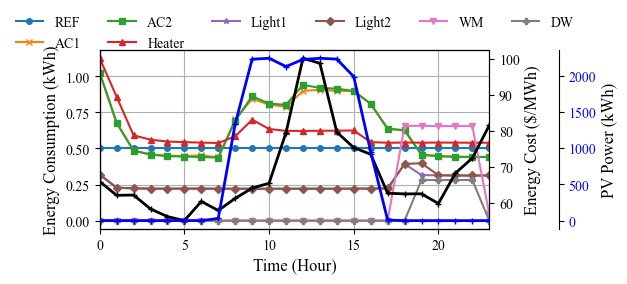

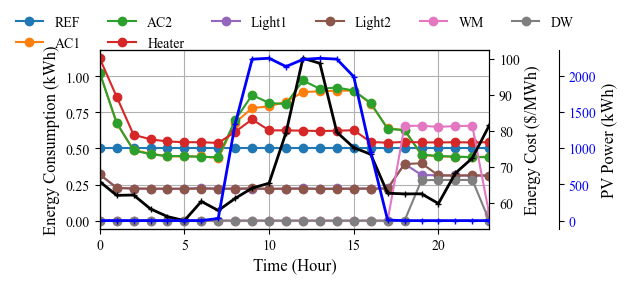

In [48]:
labels = ['REF',"AC1", "AC2", "Heater", "Light1", "Light2", 'WM', 'DW','Battery']
battery_idx = labels.index("Battery")

best = max(combo_results, key=lambda x: x["saving_mean"])
best_hourly = np.asarray(best["avg_hourly_mean"], dtype=float)  # (num_agents,24)

# choose which agents to plot (exclude battery)
plot_indices = [i for i in range(len(labels)) if i != battery_idx]

hours = np.arange(num_hours)

markers = ['o','x','s','^','*','D','v','P']

fig, ax1 = plt.subplots(figsize=(6, 3))

m = 0
for i in plot_indices:
    ax1.plot(hours, best_hourly[i], label=labels[i],
             marker=markers[m % len(markers)], markersize=4)
    m += 1

ax1.set_xlim(0, num_hours - 1)
ax1.set_xlabel('Time (Hour)')
ax1.set_ylabel('Energy Consumption (kWh)')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(hours, hourly_energy_cost*1000,  marker='+', color='k', markersize=4, linewidth=2)
ax2.set_ylabel('Energy Cost ($/MWh)')

ax3 = ax1.twinx()
ax3.plot(hours, hourly_pv_power, marker='+',color='b', markersize=4, linewidth=2)
ax3.set_ylabel('PV Power (kWh)')
ax3.tick_params('y', labelcolor='blue')
ax3.spines['right'].set_position(('outward', 50))
ax3.spines['right'].set_visible(True)

handles1, labels1_ = ax1.get_legend_handles_labels()
handles2, labels2_ = ax2.get_legend_handles_labels()
handles3, labels3_ = ax3.get_legend_handles_labels()

plt.legend(handles1 + handles2 + handles3,
           labels1_ + labels2_ + labels3_,
           loc='center', bbox_to_anchor=(0.5, 1.1),
           ncol=min(len(labels1_) + 2, 6), frameon=False)

plt.tight_layout()

# Prefer PDF/PNG to avoid transparency warnings in EPS
plt.savefig("avg_agent_power_no_battery_24h.pdf")
# or:
# plt.savefig("avg_agent_power_no_battery_24h.png", dpi=300)

hours = np.arange(24)

fig, ax1 = plt.subplots(figsize=(6, 3))

for i in range(num_agents-1):  # exclude battery
    plt.plot(hours,
             rep_profile[i,:],
             marker='o',
             linewidth=1.5,
             label=labels[i])

ax1.set_xlim(0, num_hours - 1)
ax1.set_xlabel('Time (Hour)')
ax1.set_ylabel('Energy Consumption (kWh)')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(hours, hourly_energy_cost*1000,  marker='+', color='k', markersize=4, linewidth=2)
ax2.set_ylabel('Energy Cost ($/MWh)')

ax3 = ax1.twinx()
ax3.plot(hours, hourly_pv_power, marker='+',color='b', markersize=4, linewidth=2)
ax3.set_ylabel('PV Power (kWh)')
ax3.tick_params('y', labelcolor='blue')
ax3.spines['right'].set_position(('outward', 50))
ax3.spines['right'].set_visible(True)

handles1, labels1_ = ax1.get_legend_handles_labels()
handles2, labels2_ = ax2.get_legend_handles_labels()
handles3, labels3_ = ax3.get_legend_handles_labels()

plt.legend(handles1 + handles2 + handles3,
           labels1_ + labels2_ + labels3_,
           loc='center', bbox_to_anchor=(0.5, 1.1),
           ncol=min(len(labels1_) + 2, 6), frameon=False)

plt.tight_layout()

save_figure('representative_seed_profile.eps')
plt.show()



The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


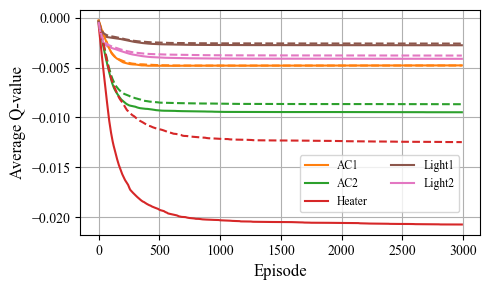

In [49]:
# ================== Plot Q‑values for best hormone vs. no hormone (ALL AGENTS, SAME AXIS) ==================
print("\nCollecting Q_values for the best hormone combination...")

# Re‑run the best hormone combo across all seeds to get Q‑values
best_mel = best['mel']
best_cor = best['cor']

hormone_runs = []
for seed in seeds:
    r = run_one(seed, modulation_mode="hormone", update_mode="qlearning",
                mel_model=best_mel, cor_model=best_cor, policy_mode="kfql", learn=True)
    hormone_runs.append(r)

# Aggregate Q‑values for best hormone
hormone_q_all = np.stack([r["q_values"] for r in hormone_runs], axis=0)  # (seeds, agents, episodes)
hormone_q_mean = np.mean(hormone_q_all, axis=0)          # (agents, episodes)
hormone_q_std  = np.std(hormone_q_all, axis=0, ddof=1)   # (agents, episodes)

# No‑hormone Q‑values are already in noh_summary
noh_q_mean = noh_summary['q_mean']      # (agents, episodes)
noh_q_std  = noh_summary['q_std']       # (agents, episodes)

# Smoothing function
def smooth_curve(values, window_size=50):
    if len(values) < window_size:
        return values
    return np.convolve(values, np.ones(window_size)/window_size, mode='valid')

window = 10
episodes_arr = np.arange(episodes)

# Prepare colours for each agent
colors = plt.cm.tab10(np.linspace(0, 1, num_agents))   # 10 distinct colors (enough for 9 agents)

# Single figure
plt.figure(figsize=(5, 3))

# Plot with hormone (solid lines)
for agent_idx in range(5):
    q_smooth = smooth_curve(hormone_q_mean[agent_idx+1], window)
    smooth_episodes = episodes_arr[:len(q_smooth)]
    plt.plot(smooth_episodes, q_smooth, 
             label=f'{labels[agent_idx+1]}', 
             color=colors[agent_idx+1], linewidth=1.5, linestyle='-')

# Plot without hormone (dashed lines)
for agent_idx in range(5):
    q_smooth = smooth_curve(noh_q_mean[agent_idx+1], window)
    smooth_episodes = episodes_arr[:len(q_smooth)]
    plt.plot(smooth_episodes, q_smooth, 
             color=colors[agent_idx+1], linewidth=1.5, linestyle='--')

plt.xlabel('Episode')
plt.ylabel('Average Q‑value')
#plt.title('Smoothed Average Q‑values for All Agents (with vs. without hormone)')
plt.grid(True)
plt.legend(ncol=2, fontsize='small', loc=(0.55,0.1))
plt.tight_layout()
save_figure('q_smooth_all_agents_same_axis.eps')
plt.show()

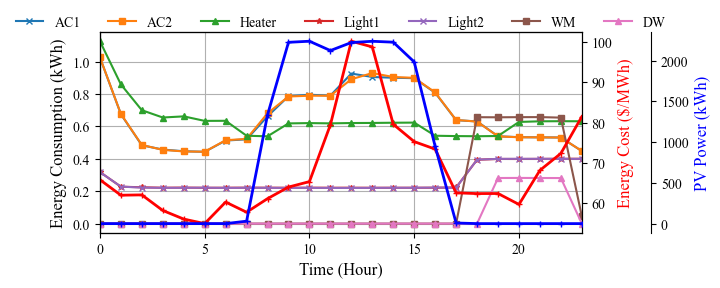

Energy w/o hormone: woh.eps


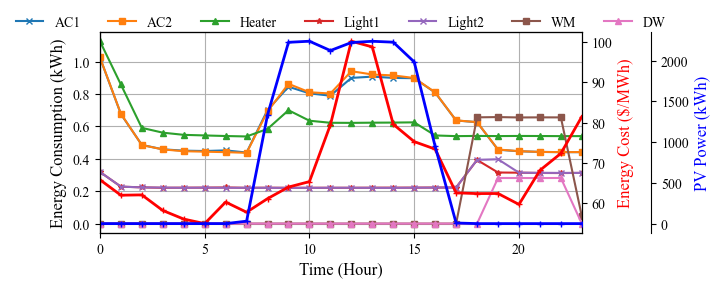

Energy with hormone:energy_wh1.eps


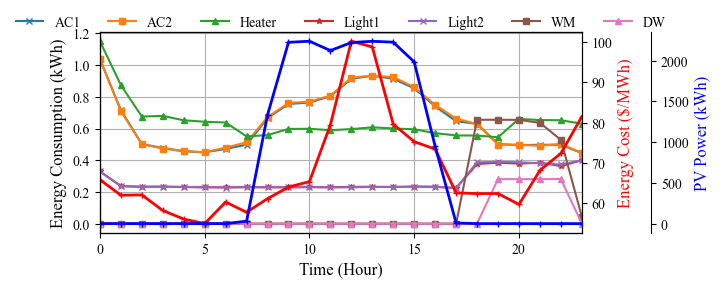

Energy w/o hormone_sarsa:energy_woh_s.eps


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


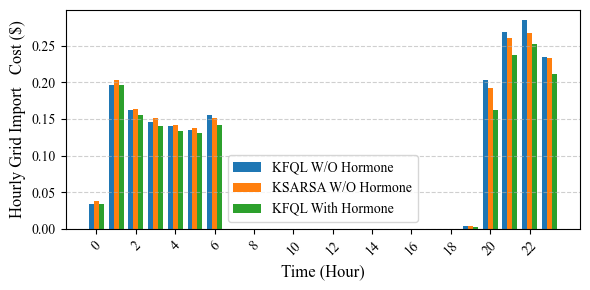

Hourly grid import cost:hourly_cost.eps


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


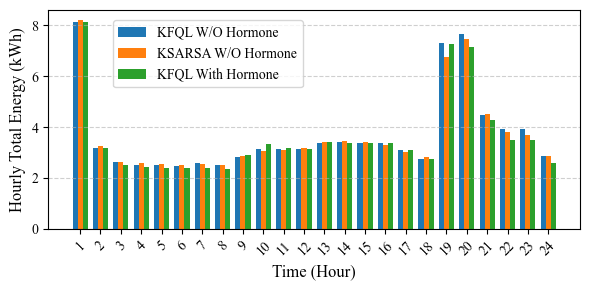

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Hourly Total Energy Cost:hourly_cost


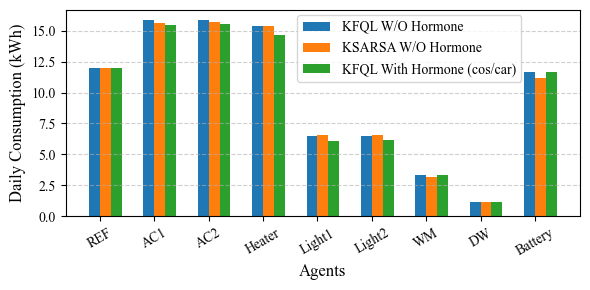

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Daily Total Energy Consumption Per Agent:daily_energy


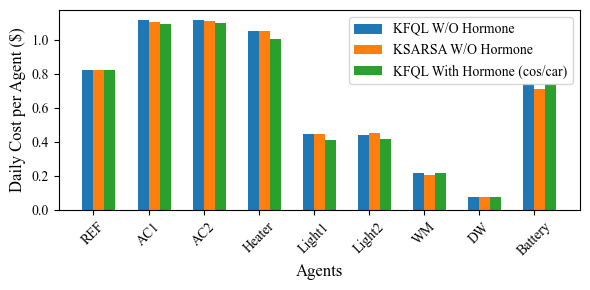

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


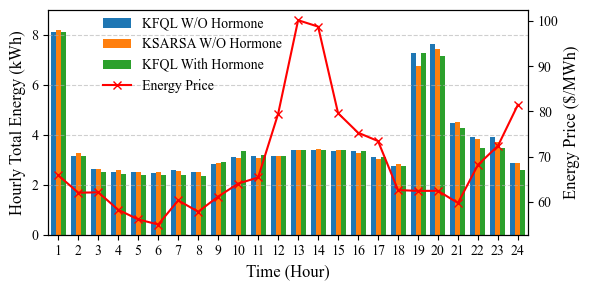

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


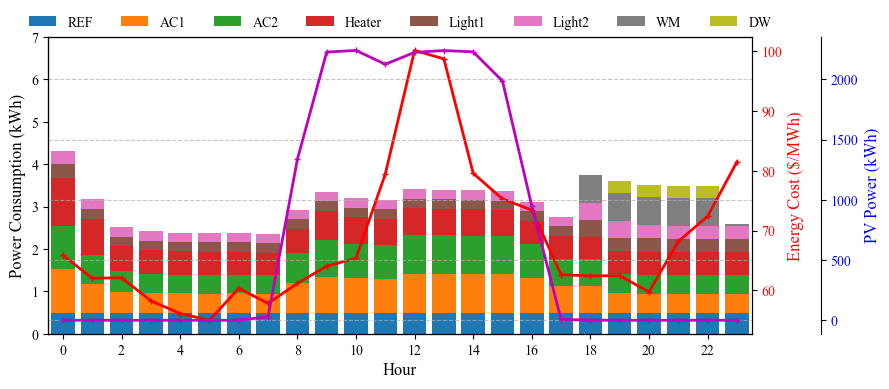

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


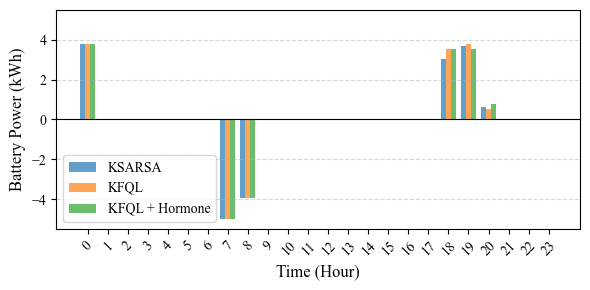

In [ ]:
# ---------------------------
# 1. Extract necessary data
# ---------------------------
avg_power_hourly_no_hormone = noh_summary['avg_hourly_mean']      # (num_agents, 24)
avg_power_hourly_sarsa      = sarsa_summary['avg_hourly_mean']    # (num_agents, 24)
avg_power_hourly_hormone    = np.array(best['avg_hourly_mean'])   # (num_agents, 24)

total_24h_no_hormone_per_agent = noh_summary['per_agent_mean']    # (num_agents,)
total_24h_sarsa_per_agent      = sarsa_summary['per_agent_mean']  # (num_agents,)
total_24h_hormone_per_agent    = best['per_agent_mean']           # (num_agents,)

# For SARSA, we also need the hourly profiles (already have avg_power_hourly_sarsa)
# For naive, we already have total_24h_naive_per_agent

# ---------------------------
# 2. Helper functions
# ---------------------------
def smooth_curve(values, window=50):
    if len(values) < window:
        return values
    return np.convolve(values, np.ones(window)/window, mode='valid')

# ---------------------------
# 3. Plotting
# ---------------------------
num_agents_plot = 8  # skip REF [0] and Battery [8]
agent_indices = list(range(1, num_agents_plot))   # AC1, AC2, Heater, L1, L2, WM, DW
markers = ['o', 'x', 's', '^', '*', 'x', 's', '^', '*']
colors = ['b', 'c', 'g', 'c', 'm' , 'y', 'g', 'r', 'm']

## =============================================================================#
##      (a) Average Hourly Energy Consumption - WITHOUT Hormone -               #
##==============================================================================#

fig, ax1 = plt.subplots(figsize=(7, 3))
for i, agent_idx in enumerate(agent_indices):
    ax1.plot(avg_power_hourly_no_hormone[agent_idx], 
             label=labels[agent_idx], 
             marker=markers[i+1], markersize=4)
ax1.set_xlim(0, num_hours-1)
ax1.set_xlabel('Time (Hour)')
ax1.set_ylabel('Energy Consumption (kWh)')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(hourly_energy_cost * 1000, 'r', marker='+', markersize=4, linewidth=2)
ax2.set_ylabel('Energy Cost ($/MWh)', color='r')

ax3 = ax1.twinx()
ax3.plot(hourly_pv_power, 'b', marker='+', markersize=4, linewidth=2)
ax3.set_ylabel('PV Power (kWh)', color='b')
ax3.spines['right'].set_position(('outward', 50))
ax3.spines['right'].set_visible(True)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
handles3, labels3 = ax3.get_legend_handles_labels()
plt.legend(handles1 + handles2 + handles3, 
           labels1 + labels2 + labels3, 
           loc='center', bbox_to_anchor=(0.5, 1.05), 
           ncol=len(labels1)+2, frameon=False)
plt.tight_layout()
save_figure("woh.eps")
plt.show()

print("Energy w/o hormone: woh.eps")
## =============================================================================#
##      (b) Average Hourly Energy Consumption - WITH Hormone (best combo) ----  #
##==============================================================================#

fig, ax1 = plt.subplots(figsize=(7, 3))
for i, agent_idx in enumerate(agent_indices):
    ax1.plot(avg_power_hourly_hormone[agent_idx], 
             label=labels[agent_idx], 
             marker=markers[i+1], markersize=4)
ax1.set_xlim(0, num_hours-1)
ax1.set_xlabel('Time (Hour)')
ax1.set_ylabel('Energy Consumption (kWh)')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(hourly_energy_cost * 1000, 'r', marker='+', markersize=4, linewidth=2)
ax2.set_ylabel('Energy Cost ($/MWh)', color='r')

ax3 = ax1.twinx()
ax3.plot(hourly_pv_power, 'b', marker='+', markersize=4, linewidth=2)
ax3.set_ylabel('PV Power (kWh)', color='b')
ax3.spines['right'].set_position(('outward', 50))
ax3.spines['right'].set_visible(True)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
handles3, labels3 = ax3.get_legend_handles_labels()
plt.legend(handles1 + handles2 + handles3, 
           labels1 + labels2 + labels3, 
           loc='center', bbox_to_anchor=(0.5, 1.05), 
           ncol=len(labels1)+2, frameon=False)
plt.tight_layout()
save_figure("energy_wh1.eps")
plt.show()

print("Energy with hormone:energy_wh1.eps")
## =============================================================================#
##      (c) Average Hourly Energy Consumption - SARSA ----                      #
##==============================================================================#

fig, ax1 = plt.subplots(figsize=(7, 3))
for i, agent_idx in enumerate(agent_indices):
    ax1.plot(avg_power_hourly_sarsa[agent_idx], 
             label=labels[agent_idx], 
             marker=markers[i+1], markersize=4)
ax1.set_xlim(0, num_hours-1)
ax1.set_xlabel('Time (Hour)')
ax1.set_ylabel('Energy Consumption (kWh)')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(hourly_energy_cost * 1000, 'r', marker='+', markersize=4, linewidth=2)
ax2.set_ylabel('Energy Cost ($/MWh)', color='r')

ax3 = ax1.twinx()
ax3.plot(hourly_pv_power, 'b', marker='+', markersize=4, linewidth=2)
ax3.set_ylabel('PV Power (kWh)', color='b')
ax3.spines['right'].set_position(('outward', 50))
ax3.spines['right'].set_visible(True)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
handles3, labels3 = ax3.get_legend_handles_labels()
plt.legend(handles1 + handles2 + handles3, 
           labels1 + labels2 + labels3, 
           loc='center', bbox_to_anchor=(0.5, 1.05), 
           ncol=len(labels1)+2, frameon=False)
plt.tight_layout()
save_figure("energy_woh_s.eps")
plt.show()
print("Energy w/o hormone_sarsa:energy_woh_s.eps")

## =============================================================================#
##               Hourly GRID-IMPORT Cost ($)(kWh) #                             #
##==============================================================================#
# 
hourly_price = hourly_energy_cost  # shape (24,)

cost_noh   = noh_summary["grid_import_hourly_mean"] * hourly_price
cost_sarsa = sarsa_summary["grid_import_hourly_mean"] * hourly_price
cost_hormone = best["grid_import_hourly_mean"] * hourly_price

x = np.arange(24)
width = 0.25

plt.figure(figsize=(6, 3))
plt.bar(x - width, cost_noh, width, label="KFQL W/O Hormone")
plt.bar(x, cost_sarsa, width, label="KSARSA W/O Hormone")
plt.bar(x + width, cost_hormone, width, label="KFQL With Hormone")
plt.xlabel("Time (Hour)")
plt.ylabel("Hourly Grid Import   Cost ($)")
plt.xticks(x[::2], [f"{h}" for h in x[::2]], rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
save_figure("hourly_cost.eps")
plt.show()

print("Hourly grid import cost:hourly_cost.eps")

## ==============================================================================
##                   Hourly Operation Cost (using total power per hour)
##===============================================================================

# Compute total hourly power (sum over agents)
hourly_power_no_hormone = avg_power_hourly_no_hormone.sum(axis=0)   # shape (24,)
hourly_power_sarsa      = avg_power_hourly_sarsa.sum(axis=0)
hourly_power_hormone    = avg_power_hourly_hormone.sum(axis=0)

# Convert to cost (assuming price in $/kWh)
cost_no_hormone = hourly_power_no_hormone   # actually cost = power * price, but here we plot power as proxy
cost_sarsa      = hourly_power_sarsa
cost_hormone    = hourly_power_hormone

x = np.arange(num_hours)
width = 0.25
plt.figure(figsize=(6, 3))
plt.bar(x - width, cost_no_hormone, width, label="KFQL W/O Hormone")
plt.bar(x, cost_sarsa, width, label="KSARSA W/O Hormone")
plt.bar(x + width, cost_hormone, width, label="KFQL With Hormone")
plt.xticks(x, [f"{h+1}" for h in range(num_hours)], rotation=45)
plt.xlabel("Time (Hour)")
plt.ylabel("Hourly Total Energy (kWh)")
plt.legend(loc='center', bbox_to_anchor=(0.3, 0.8))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
save_figure("hourly_cost.eps")
plt.show()

print("Hourly Total Energy Cost:hourly_cost")
## ==============================================================================
##                Daily Energy per Agent (bar chart)
##===============================================================================

# ---- (e) Daily Energy per Agent (bar chart) ----
bar_width = 0.2
x = np.arange(len(labels))
plt.figure(figsize=(6, 3))
plt.bar(x - 0.5*bar_width, total_24h_no_hormone_per_agent, width=bar_width, label="KFQL W/O Hormone")
plt.bar(x + 0.5*bar_width, total_24h_sarsa_per_agent, width=bar_width, label="KSARSA W/O Hormone")
plt.bar(x + 1.5*bar_width, total_24h_hormone_per_agent, width=bar_width, 
        label=f"KFQL With Hormone ({best['mel']}/{best['cor']})")
plt.xticks(x, labels, rotation=30)
plt.ylabel("Daily Consumption (kWh)")
plt.xlabel("Agents")
plt.legend(loc=(0.45,0.65))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
save_figure("daily_energy.eps")
plt.show()

print("Daily Total Energy Consumption Per Agent:daily_energy")

## ==============================================================================
##                           #
##===============================================================================
# ---- (f) Daily Cost per Agent (using price) ----
price_per_hour = hourly_energy_cost   # shape (24,)
def compute_costs(avg_hourly_power, price):
    # avg_hourly_power: (num_agents, num_hours)
    cost_per_agent = (avg_hourly_power * price).sum(axis=1)
    return cost_per_agent, cost_per_agent.sum()

# Use existing summaries
cost_no_hormone_per_agent, _ = compute_costs(avg_power_hourly_no_hormone, price_per_hour)
cost_sarsa_per_agent, _      = compute_costs(avg_power_hourly_sarsa, price_per_hour)
cost_hormone_per_agent, _    = compute_costs(avg_power_hourly_hormone, price_per_hour)

x = np.arange(len(labels))
width = 0.2
fig, ax = plt.subplots(figsize=(6,3))
# ax.bar(x - 1.5*width, cost_naive_per_agent, width, label="Baseline (No DR)")   # optional
ax.bar(x - 0.5*width, cost_no_hormone_per_agent, width, label="KFQL W/O Hormone")
ax.bar(x + 0.5*width, cost_sarsa_per_agent, width, label="KSARSA W/O Hormone")
ax.bar(x + 1.5*width, cost_hormone_per_agent, width, label=f"KFQL With Hormone ({best['mel']}/{best['cor']})")
ax.set_ylabel("Daily Cost per Agent ($)")
ax.set_xlabel("Agents")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.legend(loc='upper right')
plt.tight_layout()
save_figure("daily_cost.eps")
plt.show()

## ==============================================================================
##                           #
##===============================================================================

# ---- (g) Hourly Total Energy with Price overlay (dual axis) ----
fig, ax1 = plt.subplots(figsize=(6, 3))
x = np.arange(num_hours)
width = 0.25
ax1.bar(x - width, hourly_power_no_hormone, width, label="KFQL W/O Hormone")
ax1.bar(x, hourly_power_sarsa, width, label="KSARSA W/O Hormone")
ax1.bar(x + width, hourly_power_hormone, width, label="KFQL With Hormone")
ax1.set_ylim(0, 9)
ax1.set_xlim(-0.5, 23.5)
ax1.set_xticks(x)
ax1.set_xticklabels([f"{h+1}" for h in range(num_hours)])
ax1.set_xlabel("Time (Hour)")
ax1.set_ylabel("Hourly Total Energy (kWh)")
ax1.grid(axis='y', linestyle='--', alpha=0.6)

ax2 = ax1.twinx()
ax2.plot(x, hourly_energy_cost * 1000, 'r', marker='x', linestyle='-', label='Energy Price')
ax2.set_ylabel("Energy Price ($/MWh)", color='black')
ax2.tick_params(axis='y', labelcolor='black')

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='center', bbox_to_anchor=(0.3, 0.8), frameon=False)
plt.tight_layout()
save_figure("hourly_cost2.eps")
plt.show()

## ==============================================================================
##                           #
##===============================================================================

# ---- (h) Stacked bar chart of best hormone hourly consumption ----
bottom = np.zeros(num_hours)
hours = np.arange(num_hours)
colors_stack = plt.cm.tab10(np.linspace(0, 1, len(labels)))  # distinct colors
fig, ax1 = plt.subplots(figsize=(9, 4))
for i in range(8):
    ax1.bar(hours, avg_power_hourly_hormone[i], bottom=bottom, label=labels[i], color=colors_stack[i])
    bottom += avg_power_hourly_hormone[i]

ax1.set_xlim(-0.5, num_hours-0.5)
ax1.set_xlabel('Hour')
ax1.set_ylabel('Power Consumption (kWh)')
ax1.set_ylim(0, 7)
ax1.set_xticks(np.arange(0, num_hours, 2))

ax2 = ax1.twinx()
ax2.plot(hours, hourly_energy_cost * 1000, 'r', marker='+', markersize=4, linewidth=2)
ax2.set_ylabel('Energy Cost ($/MWh)', color='r')
ax2.tick_params('y', labelcolor='red')

ax3 = ax1.twinx()
ax3.plot(hours, hourly_pv_power, color='m', marker='+', markersize=4, linewidth=2)
ax3.set_ylabel('PV Power (kWh)', color='b')
ax3.tick_params('y', labelcolor='blue')
ax3.spines['right'].set_position(('outward', 50))
ax3.spines['right'].set_visible(True)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
handles3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(handles1 + handles2 + handles3, labels1 + labels2 + labels3, 
           loc='center', bbox_to_anchor=(0.5, 1.05), ncol=len(labels1)+2, frameon=False)
plt.tight_layout()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
save_figure("energy_stack.eps")
plt.show()


## ==============================================================================
##                           #
##===============================================================================

# Example: extract signed battery from summaries
sarsa_bat_signed   = sarsa_summary["bat_signed_mean"]    # shape (24,)
noh_bat_signed     = noh_summary["bat_signed_mean"]
hormone_bat_signed = best["bat_signed_mean"]             # from best dictionary

hours = np.arange(24)
bar_width = 0.25

hours = np.arange(24)
bar_width = 0.25

plt.figure(figsize=(6, 3))

# SARSA
plt.bar(hours - bar_width, sarsa_bat_signed, width=bar_width,
        color='#1f77b4', alpha=0.7, label='KSARSA')

# KFQL (no hormone)
plt.bar(hours, noh_bat_signed, width=bar_width,
        color='#ff7f0e', alpha=0.7, label='KFQL')

# KFQL + Hormone
plt.bar(hours + bar_width, hormone_bat_signed, width=bar_width,
        color='#2ca02c', alpha=0.7, label='KFQL + Hormone')

# Reference line at zero
plt.axhline(0, color='black', linewidth=0.8)

plt.xlabel('Time (Hour)')
plt.ylabel('Battery Power (kWh)')
plt.xticks(hours, [f'{h}' for h in hours], rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Optional: set symmetric y‑limits to emphasize positive/negative
max_abs = max(abs(sarsa_bat_signed.min()), abs(sarsa_bat_signed.max()),
              abs(noh_bat_signed.min()), abs(noh_bat_signed.max()),
              abs(hormone_bat_signed.min()), abs(hormone_bat_signed.max()))
plt.ylim(-max_abs * 1.1, max_abs * 1.1)

plt.tight_layout()
save_figure('battery_signed.eps')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


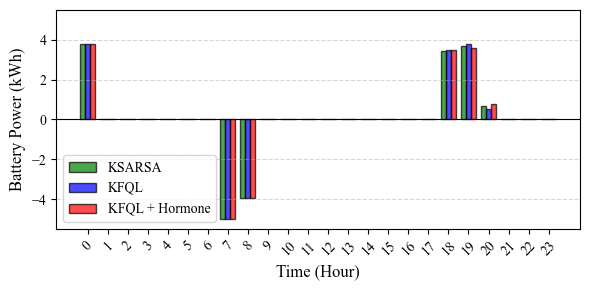

In [10]:
# Example: extract signed battery from summaries
sarsa_bat_signed   = sarsa_summary["bat_signed_mean"]    # shape (24,)
noh_bat_signed     = noh_summary["bat_signed_mean"]
hormone_bat_signed = best["bat_signed_mean"]             # from best dictionary

hours = np.arange(24)
bar_width = 0.25

hours = np.arange(24)
bar_width = 0.25

plt.figure(figsize=(6, 3))

# SARSA
plt.bar(hours - bar_width, sarsa_bat_signed, width=bar_width,
        color='green', edgecolor='black', alpha=0.7, label='KSARSA')

# KFQL (no hormone)
plt.bar(hours, noh_bat_signed, width=bar_width,
        color='blue', edgecolor='black', alpha=0.7, label='KFQL')

# KFQL + Hormone
plt.bar(hours + bar_width, hormone_bat_signed, width=bar_width,
        color='red', edgecolor='black', alpha=0.7, label='KFQL + Hormone')

# Reference line at zero
plt.axhline(0, color='black', linewidth=0.8)

plt.xlabel('Time (Hour)')
plt.ylabel('Battery Power (kWh)')
plt.xticks(hours, [f'{h}' for h in hours], rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Optional: set symmetric y‑limits to emphasize positive/negative
max_abs = max(abs(sarsa_bat_signed.min()), abs(sarsa_bat_signed.max()),
              abs(noh_bat_signed.min()), abs(noh_bat_signed.max()),
              abs(hormone_bat_signed.min()), abs(hormone_bat_signed.max()))
plt.ylim(-max_abs * 1.1, max_abs * 1.1)

plt.tight_layout()
save_figure('battery_signed.eps')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Total Daily Consumption (Excl. Battery):
  KFQL W/O Hormone: 76.91 kWh
  KSARSA W/O Hormone: 76.75 kWh
  KFQL With Hormone: 74.78 kWh


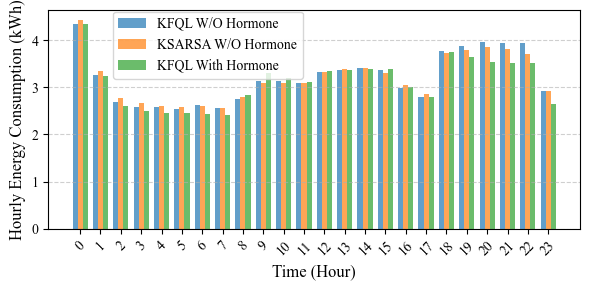

In [ ]:
# ================== Average Hourly Consumption (Excluding Battery) ==================
# Exclude battery agent (index 8) from the summation
# Battery charging/discharging should not be counted as household consumption

# avg_hourly_mean from summaries (exclude battery)
# avg_hourly_mean shape: (num_agents, 24)
hourly_power_no_hormone = noh_summary['avg_hourly_mean'][:8].sum(axis=0)   # exclude battery (index 8)
hourly_power_sarsa = sarsa_summary['avg_hourly_mean'][:8].sum(axis=0)     # exclude battery
hourly_power_hormone = best['avg_hourly_mean'][:8].sum(axis=0)            # exclude battery

# === Optional: Convert to cost if needed ===
hourly_price = hourly_energy_cost  # $/kWh

# Cost based on consumption (excluding battery)
cost_no_hormone = hourly_power_no_hormone * hourly_price
cost_sarsa = hourly_power_sarsa * hourly_price
cost_hormone = hourly_power_hormone * hourly_price

print(f"Total Daily Consumption (Excl. Battery):")
print(f"  KFQL W/O Hormone: {np.sum(hourly_power_no_hormone):.2f} kWh")
print(f"  KSARSA W/O Hormone: {np.sum(hourly_power_sarsa):.2f} kWh")
print(f"  KFQL With Hormone: {np.sum(hourly_power_hormone):.2f} kWh")

# === Plot grouped bar chart ===
x = np.arange(num_hours)
bar_width = 0.25

plt.figure(figsize=(6, 3))
plt.bar(x - bar_width, hourly_power_no_hormone, width=bar_width, 
        label="KFQL W/O Hormone", color='#1f77b4', alpha=0.7)
plt.bar(x, hourly_power_sarsa, width=bar_width, 
        label="KSARSA W/O Hormone", color='#ff7f0e', alpha=0.7)
plt.bar(x + bar_width, hourly_power_hormone, width=bar_width, 
        label="KFQL With Hormone", color='#2ca02c', alpha=0.7)

plt.xticks(x[::1], [f"{h}" for h in x[::1]], rotation=45)
plt.xlabel("Time (Hour)")
plt.ylabel("Hourly Energy Consumption (kWh)")
plt.legend(loc='center', bbox_to_anchor=(0.3, 0.84))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
save_figure("hourly_consumption_excl_battery.eps")
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


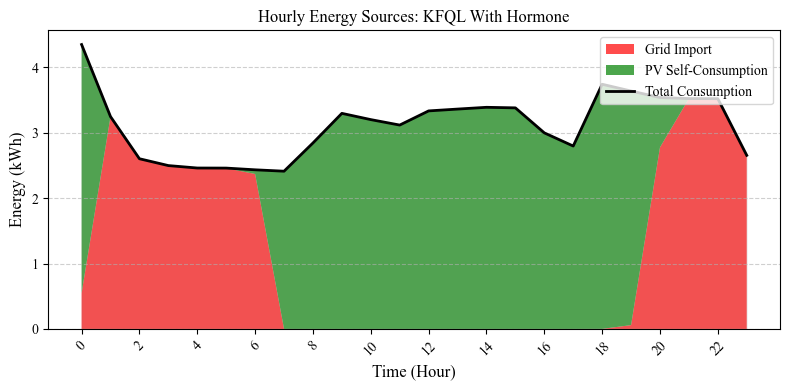

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


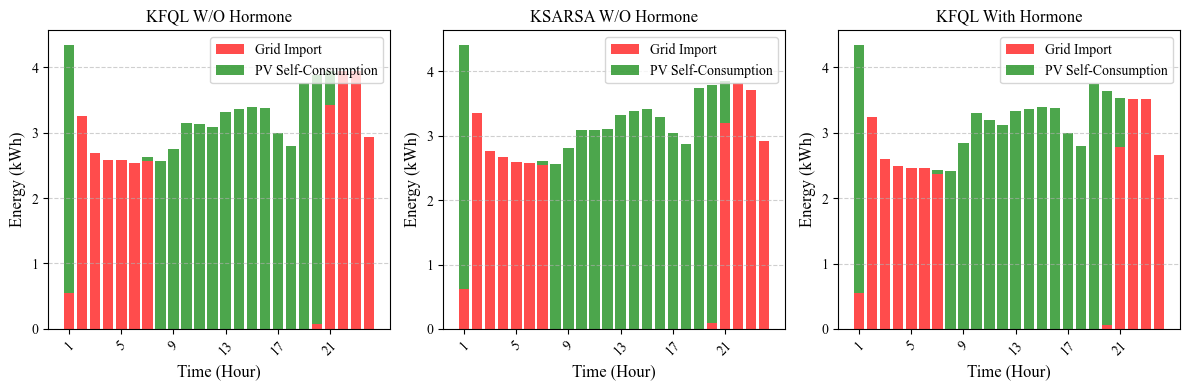

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


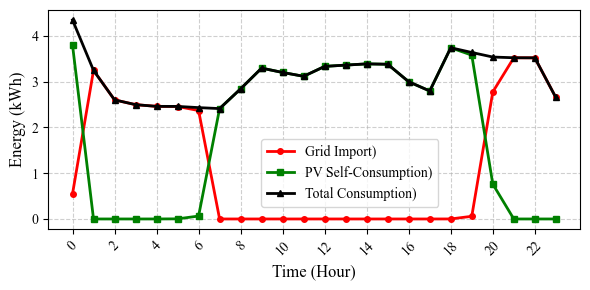

Hourly energy breakdow KFQL with hormone

=== Daily Energy Summary (Excluding Battery) ===
Method                    Total Consumption    Grid Import          PV Self-Consumption 
-------------------------------------------------------------------------------------
KFQL W/O Hormone          76.91                31.07                45.85               
KSARSA W/O Hormone        76.75                30.84                45.91               
KFQL With Hormone         74.78                28.71                46.07               


In [76]:
# ================== Hourly Energy Consumption: Grid + PV (Excluding Battery) ==================
# This plot shows the source of energy for household consumption:
# - Grid import (what you pay for)
# - PV self-consumption (free energy from solar)

hourly_price = hourly_energy_cost  # shape (24,)

# Get hourly grid import (what comes from grid)
grid_import_noh = noh_summary["grid_import_hourly_mean"]      # shape (24,)
grid_import_sarsa = sarsa_summary["grid_import_hourly_mean"]  # shape (24,)
grid_import_hormone = best["grid_import_hourly_mean"]         # shape (24,)

# Get total household consumption (excluding battery)
# This includes all appliances: REF, AC1, AC2, Heater, Light1, Light2, WM, DW
hourly_consumption_noh = noh_summary['avg_hourly_mean'][:8].sum(axis=0)
hourly_consumption_sarsa = sarsa_summary['avg_hourly_mean'][:8].sum(axis=0)
hourly_consumption_hormone = best['avg_hourly_mean'][:8].sum(axis=0)

# Calculate PV self-consumption = Total consumption - Grid import
# (assuming no battery charging/discharging)
pv_self_consumption_noh = hourly_consumption_noh - grid_import_noh
pv_self_consumption_sarsa = hourly_consumption_sarsa - grid_import_sarsa
pv_self_consumption_hormone = hourly_consumption_hormone - grid_import_hormone

# Clip to zero (should be non-negative, but numerical issues may occur)
pv_self_consumption_noh = np.maximum(pv_self_consumption_noh, 0)
pv_self_consumption_sarsa = np.maximum(pv_self_consumption_sarsa, 0)
pv_self_consumption_hormone = np.maximum(pv_self_consumption_hormone, 0)

# ========== Plot 1: Stacked Area Chart for Best Method (KFQL + Hormone) ==========
x = np.arange(num_hours)

plt.figure(figsize=(8, 4))
plt.stackplot(x, grid_import_hormone, pv_self_consumption_hormone,
              labels=['Grid Import', 'PV Self-Consumption'],
              colors=['red', 'green'], alpha=0.7)
plt.plot(x, hourly_consumption_hormone, 'k-', linewidth=2, label='Total Consumption')
plt.fill_between(x, 0, hourly_consumption_hormone, alpha=0.1, color='gray')
plt.xlabel('Time (Hour)')
plt.ylabel('Energy (kWh)')
plt.title('Hourly Energy Sources: KFQL With Hormone')
plt.xticks(x[::2], [f'{h}' for h in x[::2]], rotation=45)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
save_figure("energy_sources_hormone.eps")
plt.show()

# ========== Plot 2: Side-by-Side Stacked Bars for All Three Methods ==========
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

methods = [
    (grid_import_noh, pv_self_consumption_noh, "KFQL W/O Hormone"),
    (grid_import_sarsa, pv_self_consumption_sarsa, "KSARSA W/O Hormone"),
    (grid_import_hormone, pv_self_consumption_hormone, "KFQL With Hormone")
]

for idx, (grid, pv, title) in enumerate(methods):
    ax = axes[idx]
    ax.bar(x, grid, width=0.8, label='Grid Import', color='red', alpha=0.7)
    ax.bar(x, pv, width=0.8, bottom=grid, label='PV Self-Consumption', color='green', alpha=0.7)
    ax.set_xlabel('Time (Hour)')
    ax.set_ylabel('Energy (kWh)')
    ax.set_title(title)
    ax.set_xticks(x[::4])
    ax.set_xticklabels([f'{h+1}' for h in x[::4]], rotation=45)
    ax.legend(loc='upper right')
    ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
save_figure("energy_sources_comparison.eps")
plt.show()

# ========== Plot 3: Line Plot Comparison ==========
plt.figure(figsize=(6, 3))
plt.plot(x, grid_import_hormone, 'r-o', label='Grid Import)', linewidth=2, markersize=4)
plt.plot(x, pv_self_consumption_hormone, 'g-s', label='PV Self-Consumption)', linewidth=2, markersize=4)
plt.plot(x, hourly_consumption_hormone, 'k-^', label='Total Consumption)', linewidth=2, markersize=4)
plt.xlabel('Time (Hour)')
plt.ylabel('Energy (kWh)')
#plt.title('Hourly Energy Breakdown: KFQL With Hormone')
plt.xticks(x[::2], [f'{h}' for h in x[::2]], rotation=45)
plt.legend(loc=(0.4,0.1))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
save_figure("energy_breakdown_line.eps")
plt.show()

print("Hourly energy breakdow KFQL with hormone")
# ========== Print Summary Statistics ==========
print("\n=== Daily Energy Summary (Excluding Battery) ===")
print(f"{'Method':<25} {'Total Consumption':<20} {'Grid Import':<20} {'PV Self-Consumption':<20}")
print("-" * 85)
print(f"{'KFQL W/O Hormone':<25} {np.sum(hourly_consumption_noh):<20.2f} {np.sum(grid_import_noh):<20.2f} {np.sum(pv_self_consumption_noh):<20.2f}")
print(f"{'KSARSA W/O Hormone':<25} {np.sum(hourly_consumption_sarsa):<20.2f} {np.sum(grid_import_sarsa):<20.2f} {np.sum(pv_self_consumption_sarsa):<20.2f}")
print(f"{'KFQL With Hormone':<25} {np.sum(hourly_consumption_hormone):<20.2f} {np.sum(grid_import_hormone):<20.2f} {np.sum(pv_self_consumption_hormone):<20.2f}")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


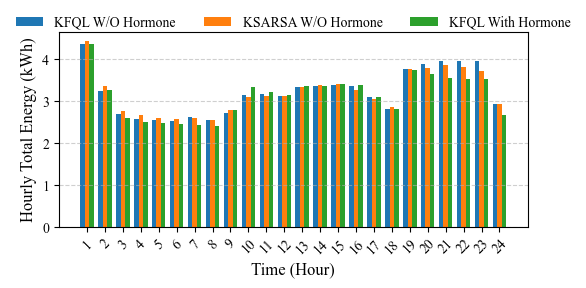

In [36]:
# ---- (d) Hourly Total Energy (excluding battery) ----
# Compute total hourly power (sum over agents, EXCLUDING battery)
hourly_power_no_hormone = avg_power_hourly_no_hormone[:8].sum(axis=0)   # shape (24,)
hourly_power_sarsa      = avg_power_hourly_sarsa[:8].sum(axis=0)
hourly_power_hormone    = avg_power_hourly_hormone[:8].sum(axis=0)

# Plot total energy (kWh) - this is actual household consumption
x = np.arange(num_hours)
width = 0.25
plt.figure(figsize=(6, 3))
plt.bar(x - width, hourly_power_no_hormone, width, label="KFQL W/O Hormone")
plt.bar(x, hourly_power_sarsa, width, label="KSARSA W/O Hormone")
plt.bar(x + width, hourly_power_hormone, width, label="KFQL With Hormone")
plt.xticks(x, [f"{h+1}" for h in range(num_hours)], rotation=45)
plt.xlabel("Time (Hour)")
plt.ylabel("Hourly Total Energy (kWh)")
#plt.title("Household Consumption (Excluding Battery)")
plt.legend(loc='center', bbox_to_anchor=(0.5, 1.05), ncol=3, frameon=False)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
save_figure("hourly_consumption_excl_battery.eps")
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


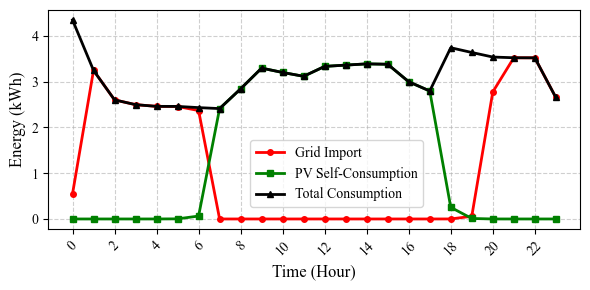

Hourly energy breakdow KFQL with hormone


[Text(0, 0, '0'),
 Text(4, 0, '4'),
 Text(8, 0, '8'),
 Text(12, 0, '12'),
 Text(16, 0, '16'),
 Text(20, 0, '20')]

In [82]:
# ── Step 1: get battery discharge hourly log ──────────────────────────────
# Battery index is 8 (last agent). Negative action = charging, positive = discharging
# avg_hourly_mean[8] is the mean battery power per hour (signed)
battery_noh     = noh_summary['avg_hourly_mean'][8]       # signed: neg=charge, pos=discharge
battery_sarsa   = sarsa_summary['avg_hourly_mean'][8]
battery_hormone = best['avg_hourly_mean'][8]

# Discharge contribution (positive only = energy flowing OUT of battery to loads)
bat_discharge_noh     = np.maximum(battery_noh, 0)
bat_discharge_sarsa   = np.maximum(battery_sarsa, 0)
bat_discharge_hormone = np.maximum(battery_hormone, 0)

# ── Step 2: correct PV self-consumption ───────────────────────────────────
# PV_self = Total_consumption - Grid_import - Battery_discharge
pv_self_consumption_noh     = hourly_consumption_noh     - grid_import_noh     - bat_discharge_noh
pv_self_consumption_sarsa   = hourly_consumption_sarsa   - grid_import_sarsa   - bat_discharge_sarsa
pv_self_consumption_hormone = hourly_consumption_hormone - grid_import_hormone - bat_discharge_hormone

# Clip negatives from numerical noise
pv_self_consumption_noh     = np.maximum(pv_self_consumption_noh, 0)
pv_self_consumption_sarsa   = np.maximum(pv_self_consumption_sarsa, 0)
pv_self_consumption_hormone = np.maximum(pv_self_consumption_hormone, 0)

# ========== Plot 3: Line Plot Comparison ==========
plt.figure(figsize=(6, 3))
plt.plot(x, grid_import_hormone, 'r-o', label='Grid Import', linewidth=2, markersize=4)
plt.plot(x, pv_self_consumption_hormone, 'g-s', label='PV Self-Consumption', linewidth=2, markersize=4)
plt.plot(x, hourly_consumption_hormone, 'k-^', label='Total Consumption', linewidth=2, markersize=4)
plt.xlabel('Time (Hour)')
plt.ylabel('Energy (kWh)')
#plt.title('Hourly Energy Breakdown: KFQL With Hormone')
plt.xticks(x[::2], [f'{h}' for h in x[::2]], rotation=45)
plt.legend(loc=(0.38,0.1))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
save_figure("energy_breakdown_line.eps")
plt.show()

print("Hourly energy breakdow KFQL with hormone")

# Plot 2 fix (inside the loop):
ax.set_xticklabels([f'{h}' for h in x[::4]], rotation=45)  # was f'{h+1}'